# FCFF DCF Valuation v1
## Sales-driven FCFF 모델 기반 미국 주식 내재가치 계산

### 처리 흐름
```
①  DB (us_revenue_forecast_data) → 과거 Sales + 12분기 예측 Sales
②  FMP API → IS / BS / CF 분기 데이터
③  Sales-driven 회귀
      OPM  = f(Sales)      [SARIMA/ETS/Theta Ensemble 예측]
      D&A  = α × Sales     [OLS 또는 median ratio fallback]
      CapEx= β × Sales     [OLS 또는 median ratio fallback]
      NWC  = γ × Sales     [OLS 또는 median ratio fallback]
      ΔNWC = NWC_t - NWC_{t-1}
④  FCFF = EBIT×(1-tax) + D&A - CapEx - ΔNWC
⑤  WACC = Re×(E/V) + Rd×(1-tax)×(D/V)
      Re   : us_rim_spread_data 의 Re_smooth
⑥  Terminal Value = FCFF_last×(1+g) / (WACC-g)
⑦  EV = Σ FCFF/(1+WACC)^t + TV
      Target Price = (EV - Net Debt) / shares
⑧  DB 저장 + 시각화
```

---
| 셀  | 역할 |
|-----|------|
| 1   | 경로 자동 감지 |
| 2   | Import & 설정 상수 |
| 3   | DB 연결 & 테이블 초기화 |
| 4   | DCFModel 클래스 정의 |
| 5   | 배치 실행 |
| 6   | 결과 조회 & 시각화 |


## Cell 1 · 경로 자동 감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root 자동 감지 : {root}")
            return root
    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "DATA")):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f"[PATH] root 후보 경로 : {candidate}")
            return candidate
    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다.\n"
        "_CANDIDATE_ROOTS 를 현재 환경에 맞게 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")


[PATH] root 자동 감지 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · Import & 설정 상수

> **여기만 수정하면 됩니다**: `TICKER_START / TICKER_END / SKIP_DONE / DISCOUNT_MODE`

In [2]:
# ── 표준 라이브러리 ──────────────────────────────────────────────
import gc, math, time, traceback, warnings
import requests
from datetime import datetime
from typing import Optional, Dict, Any, List, Tuple

# ── 외부 라이브러리 ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

# ── 내부 모듈 ────────────────────────────────────────────────────
from DATA.config import get_db_info, get_engine
from DATA.us_target_ticker_list_2000 import ticker_list as US_TICKER_LIST
from DATA.universal_ts_forecast_function_v2 import (
    forecast_sarima, forecast_ets, forecast_theta,
    infer_freq_alias, seasonal_periods_from_freq, clear_memory,
)

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ══════════════════════════════════════════════════════════════════
#  설정 상수 — 여기만 수정하세요
# ══════════════════════════════════════════════════════════════════
FMP_API_KEY   = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"
FMP_BASE      = "https://financialmodelingprep.com/api/v3"
FMP_LIMIT     = 40          # 분기 수 (최대 조회)
FMP_SLEEP     = 0.35        # API 호출 간격 (초)

# DB 테이블
TABLE_SALES    = "us_revenue_forecast_data"   # Sales 예측 결과
TABLE_RE       = "us_rim_spread_data"         # Re_smooth
TABLE_RESULT   = "us_fcff_dcf_valuation"      # 저장 결과
DEFAULT_PORT   = 3307

# 모델 파라미터
FORECAST_HORIZON   = 8        # 예측 분기 수
MIN_HISTORY        = 20        # OPM 회귀 최소 분기 수
WINSORIZE_LIMITS   = (0.05, 0.95)
DISCOUNT_MODE      = "wacc"    # 'wacc' or 're'
GDP_GROWTH         = 0.04      # terminal growth 상한

# OLS fallback 기준
OLS_MIN_R2         = 0.30
OLS_MIN_SAMPLES    = 20

# 배치 범위 (필요 시 조정)
TICKER_START = 0
TICKER_END   = 1000 #len(US_TICKER_LIST)
SKIP_DONE    = True

CHECKPOINT_DIR = "_fcff_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DONE_PATH = os.path.join(CHECKPOINT_DIR, "done_tickers.txt")
FAIL_PATH = os.path.join(CHECKPOINT_DIR, "failed_tickers.txt")

db_info = get_db_info()
engine  = get_engine(db_info)

print(f"[OK] Import 완료  |  대상 티커: {len(US_TICKER_LIST):,}개")
print(f"[설정] DISCOUNT_MODE={DISCOUNT_MODE}  FORECAST_HORIZON={FORECAST_HORIZON}  GDP_GROWTH={GDP_GROWTH}")


[OK] Import 완료  |  대상 티커: 2,000개
[설정] DISCOUNT_MODE=wacc  FORECAST_HORIZON=8  GDP_GROWTH=0.04


## Cell 3 · DB 연결 & 결과 테이블 초기화

In [3]:
# ── DB 연결 함수 ────────────────────────────────────────────────
def get_conn():
    return pymysql.connect(
        host       = db_info["host"],
        port       = int(db_info.get("port", DEFAULT_PORT)),
        user       = db_info["user"],
        password   = db_info["password"],
        db         = db_info.get("database", "investar"),
        charset    = "utf8mb4",
        autocommit = False,
        cursorclass= pymysql.cursors.DictCursor,
    )

# ── 결과 테이블 생성 ─────────────────────────────────────────────
CREATE_SQL = """
CREATE TABLE IF NOT EXISTS `us_fcff_dcf_valuation` (
  `id`                BIGINT      NOT NULL AUTO_INCREMENT,
  `date`              DATE        NOT NULL COMMENT '예측 실행일',
  `ticker`            VARCHAR(20) NOT NULL,
  `quarter`           VARCHAR(10)          COMMENT 'e.g. 2026Q1',
  `sales_actual`      DOUBLE               COMMENT '과거 Sales',
  `sales_forecast`    DOUBLE               COMMENT '예측 Sales',
  `opm_forecast`      DOUBLE               COMMENT '예측 OPM',
  `ebit`              DOUBLE,
  `tax_rate`          DOUBLE,
  `nopat`             DOUBLE,
  `da`                DOUBLE,
  `capex`             DOUBLE,
  `nwc`               DOUBLE,
  `delta_nwc`         DOUBLE,
  `fcff`              DOUBLE,
  `roic`              DOUBLE,
  `reinvestment_rate` DOUBLE,
  `g_terminal`        DOUBLE,
  `discount_rate`     DOUBLE,
  `enterprise_value`  DOUBLE,
  `net_debt`          DOUBLE,
  `equity_value`      DOUBLE,
  `shares`            DOUBLE,
  `target_price`      DOUBLE,
  `current_price`     DOUBLE,
  `upside_pct`        DOUBLE,
  `created_at`        DATETIME    DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`, `quarter`),
  INDEX idx_ticker (`ticker`),
  INDEX idx_date   (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""

conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"테이블 준비 완료: {TABLE_RESULT}")
finally:
    conn.close()

# 연결 테스트
try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"연결 성공  host={db_info.get('host')}  port={db_info.get('port')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")


[00:18:52][DB] 테이블 준비 완료: us_fcff_dcf_valuation
[00:18:52][DB] 연결 성공  host=192.168.0.230  port=3307


## Cell 4 · DCFModel 클래스

### 클래스 구조
| 메서드 | 역할 |
|--------|------|
| `load_sales()` | DB → 과거 + 예측 Sales |
| `load_financials()` | FMP → IS/BS/CF |
| `estimate_tax_rate()` | 실효세율 (pretaxIncome>0 분기) |
| `estimate_opm()` | SARIMA/ETS/Theta Ensemble OPM 예측 |
| `estimate_ratio_coef()` | D&A/CapEx OLS 또는 median ratio |
| `estimate_nwc_coef()` | NWC/Sales 계수 |
| `compute_fcff()` | FCFF = NOPAT + D&A - CapEx - ΔNWC |
| `compute_wacc()` | WACC (Re_smooth + Rd) |
| `compute_terminal_growth()` | g = min(GDP, 0.5×CAGR + 0.5×ROIC×reinv) |
| `compute_valuation()` | DCF → EV → TP |
| `save_to_db()` | 결과 DB 저장 |
| `plot()` | 4패널 시각화 |
| `run()` | 전체 실행 |

[OK] DCFModel 클래스 & process_one_ticker 정의 완료

[테스트] AMAT 단일 실행 ...
[00:18:52][AMAT] forecast_date=2026-04-03  models=['Ensemble', 'ETS', 'LSTM', 'Prophet', 'SARIMA', 'Theta']
[00:18:52][AMAT] Sales 로드 완료  actual=85Q  forecast=8Q  model=Ensemble  forecast_date=2026-04-03
[00:18:56][AMAT] IS=40Q / BS=40Q / CF=40Q
[메모리] forecast_sarima 실행 전: 438.59 MB
[메모리] find_best_sarima_params 실행 전: 438.61 MB
[메모리] find_best_sarima_params 실행 후: 441.34 MB (변화: +2.74 MB)
[메모리] forecast_sarima 실행 후: 441.41 MB (변화: +2.82 MB)
[메모리] forecast_ets 실행 전: 441.41 MB
[메모리] forecast_ets 실행 후: 441.68 MB (변화: +0.27 MB)
[메모리] forecast_theta 실행 전: 441.68 MB
[메모리] forecast_theta 실행 후: 441.84 MB (변화: +0.16 MB)
[00:19:07][AMAT] D&A: OLS 부적합(R²=0.229) → median ratio=0.020074
[00:19:07][AMAT] CapEx: OLS slope=0.083124 R²=0.552
[00:19:08][AMAT] WACC=0.1708  Re=0.1746 Rd=0.0103 tax=0.2100
[00:19:08][AMAT] EVA: ROIC=29.90%  WACC=17.08%  spread=+12.83%  n_pos(20Q)=20/20
[00:19:08][AMAT] Moat: [Narrow moat]  spread=+12.83%  n_p

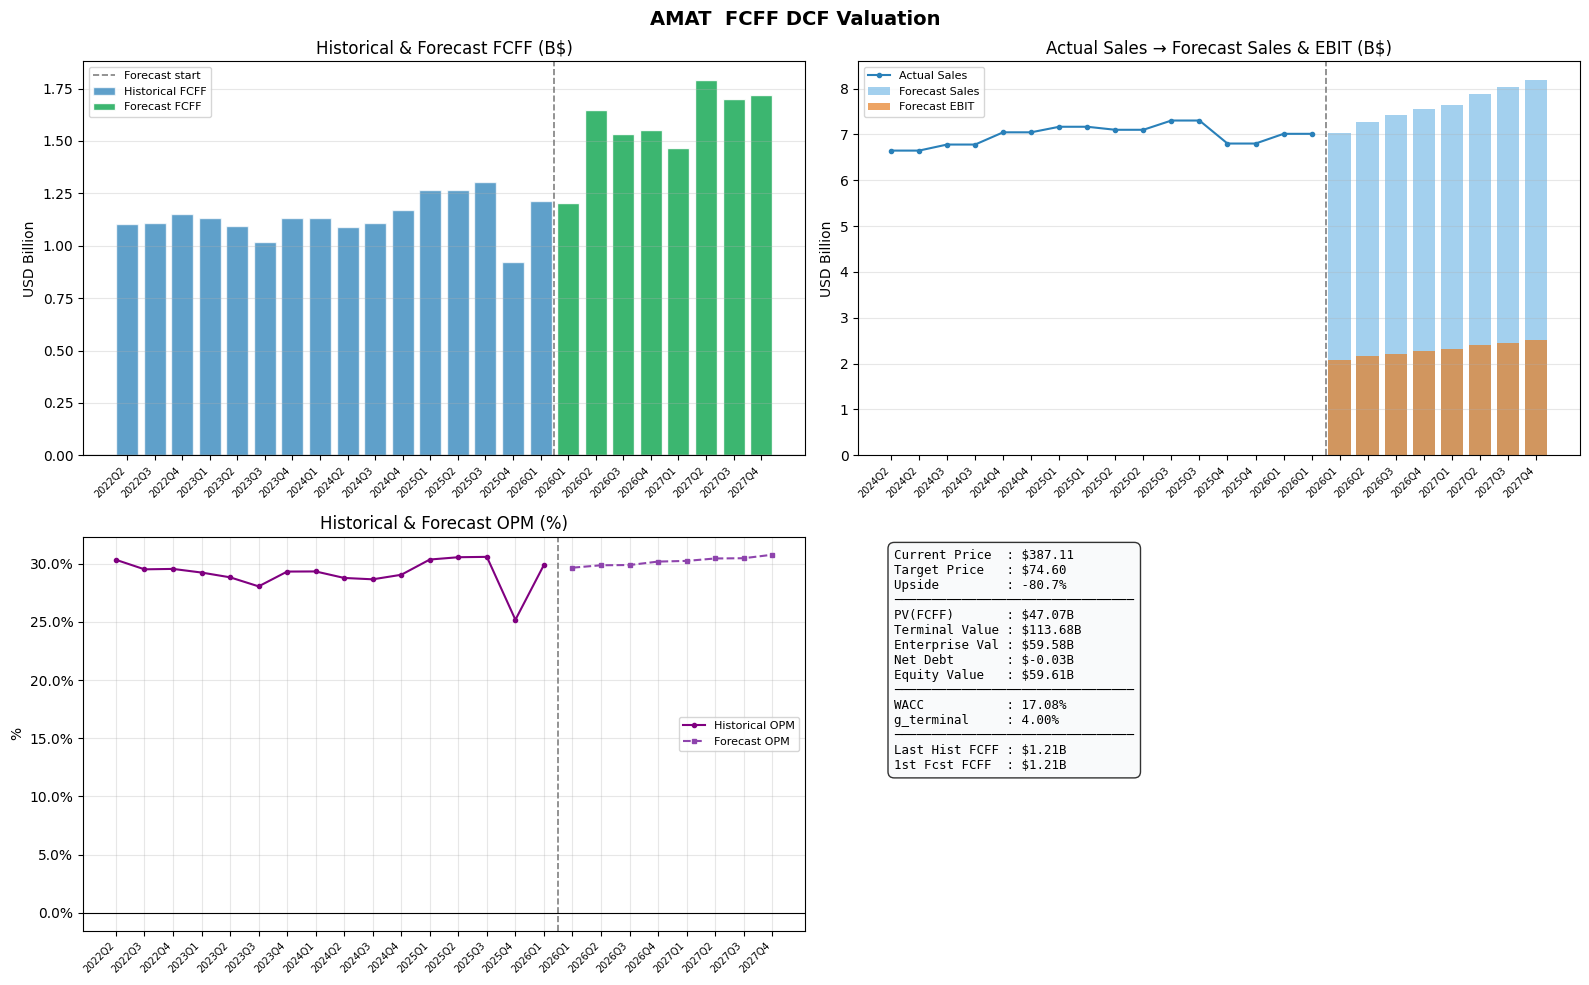

In [4]:
# ═══════════════════════════════════════════════════════════════
#  DCFModel 클래스
# ═══════════════════════════════════════════════════════════════

class DCFModel:
    """
    Sales-driven FCFF DCF Valuation Model

    Parameters
    ----------
    ticker : str
    engine : SQLAlchemy engine  (Sales DB 조회용)
    fmp_api_key : str
    forecast_horizon : int      (예측 분기 수, default 12)
    min_history : int           (OPM 회귀 최소 관측치, default 16)
    discount_mode : str         'wacc' or 're'
    gdp_growth : float          terminal growth 상한 (default 0.04)
    verbose : bool              디버그 출력 여부
    """

    def __init__(
        self,
        ticker: str,
        engine,
        fmp_api_key: str = FMP_API_KEY,
        forecast_horizon: int = FORECAST_HORIZON,
        min_history: int = MIN_HISTORY,
        discount_mode: str = DISCOUNT_MODE,
        gdp_growth: float = GDP_GROWTH,
        verbose: bool = False,
    ):
        self.ticker           = ticker.upper()
        self.engine           = engine
        self.api_key          = fmp_api_key
        self.horizon          = forecast_horizon
        self.min_history      = min_history
        self.discount_mode    = discount_mode
        self.gdp_growth       = gdp_growth
        self.verbose          = verbose

        # 내부 저장소
        self._sales_actual:   Optional[pd.Series] = None
        self._sales_forecast: Optional[pd.Series] = None
        self._inc:            Optional[pd.DataFrame] = None
        self._bs:             Optional[pd.DataFrame] = None
        self._cf:             Optional[pd.DataFrame] = None
        self._fcff_history:   Optional[pd.Series] = None
        self.result_df:       Optional[pd.DataFrame] = None
        self.valuation:       Optional[Dict] = None

    # ─────────────────────────────────────────────────────────────
    # 1. 데이터 로드
    # ─────────────────────────────────────────────────────────────

    def load_sales(self) -> "DCFModel":
        """
        DB (us_revenue_forecast_data) 에서 Sales 로드.
        ★ cursor.execute → fetchall → pd.DataFrame 패턴 (pd.read_sql + pymysql 비호환 방지)
        ★ forecast_date 가 가장 최신인 행만 사용
        ★ forecast: model 우선순위 Ensemble → SARIMA → ETS → Theta
        """
        conn_local = get_conn()
        try:
            # ── actual: data_type='actual' 전체 ────────────────────
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT date, data_type, model, value "
                    f"FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='actual' "
                    f"ORDER BY date",
                    (self.ticker,)
                )
                actual_rows = cur.fetchall()

            # ── forecast: 가장 최신 forecast_date 의 행만 ──────────
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT MAX(forecast_date) AS max_fd "
                    f"FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='forecast'",
                    (self.ticker,)
                )
                row = cur.fetchone()
                max_fd = row["max_fd"] if row else None

            if max_fd is None:
                fc_rows = []
            else:
                with conn_local.cursor() as cur:
                    cur.execute(
                        f"SELECT date, data_type, model, value "
                        f"FROM `{TABLE_SALES}` "
                        f"WHERE ticker=%s AND item='sale' "
                        f"  AND data_type='forecast' "
                        f"  AND forecast_date=%s "
                        f"ORDER BY model, date",
                        (self.ticker, max_fd)
                    )
                    fc_rows = cur.fetchall()
        finally:
            conn_local.close()

        # ── actual 처리 ─────────────────────────────────────────────
        if not actual_rows:
            raise ValueError(f"[{self.ticker}] Sales actual 데이터 없음 — us_revenue_forecast_notebook 먼저 실행")

        act_df = pd.DataFrame(actual_rows)
        act_df["date"]  = pd.to_datetime(act_df["date"])
        act_df["value"] = pd.to_numeric(act_df["value"], errors="coerce")
        actual = (act_df.sort_values("date")
                        .drop_duplicates("date", keep="last")
                        .set_index("date")["value"])

        # ── forecast 처리 ──────────────────────────────────────────
        if not fc_rows:
            raise ValueError(
                f"[{self.ticker}] forecast Sales 없음 "
                f"(forecast_date={max_fd}) — us_revenue_forecast_notebook 먼저 실행"
            )

        fc_df = pd.DataFrame(fc_rows)
        fc_df["date"]  = pd.to_datetime(fc_df["date"])
        fc_df["value"] = pd.to_numeric(fc_df["value"], errors="coerce")

        if self.verbose:
            models_in_db = fc_df["model"].unique().tolist()
            log(self.ticker, f"forecast_date={max_fd}  models={models_in_db}")

        # 우선순위: Ensemble → SARIMA → ETS → Theta → 첫 번째 모델
        priority = ["Ensemble", "SARIMA", "ETS", "Theta"]
        available = fc_df["model"].unique().tolist()
        ordered   = [m for m in priority if m in available] +                     [m for m in available if m not in priority]

        forecast = pd.Series(dtype=float)
        used_model = None
        for model_name in ordered:
            fc = (fc_df[fc_df["model"] == model_name]
                  .sort_values("date")
                  .drop_duplicates("date", keep="last")
                  .set_index("date")["value"]
                  .dropna())
            if len(fc) >= self.horizon:
                forecast  = fc.iloc[:self.horizon]
                used_model = model_name
                break
            elif len(fc) > 0 and len(forecast) == 0:
                # 부족해도 일단 보관 (마지막 fallback)
                forecast   = fc
                used_model = model_name

        if forecast.empty:
            raise ValueError(
                f"[{self.ticker}] 예측 Sales 값이 모두 비어있음 "
                f"(forecast_date={max_fd})"
            )

        # horizon 부족 시 마지막 값으로 forward-fill
        if len(forecast) < self.horizon:
            extra_idx = pd.date_range(
                start=forecast.index[-1] + pd.offsets.QuarterEnd(1),
                periods=self.horizon - len(forecast),
                freq="QE"
            )
            fill_val  = float(forecast.iloc[-1])
            forecast  = pd.concat([
                forecast,
                pd.Series([fill_val] * len(extra_idx), index=extra_idx)
            ])
            if self.verbose:
                log(self.ticker, f"  forecast 부족({len(forecast)-len(extra_idx)}개) → 마지막값 forward-fill")

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:self.horizon]
        if self.verbose:
            log(self.ticker,
                f"Sales 로드 완료  actual={len(actual)}Q  "
                f"forecast={len(self._sales_forecast)}Q  "
                f"model={used_model}  forecast_date={max_fd}")
        return self

    def _fmp_get(self, endpoint: str, period: str = "quarter", limit: int = FMP_LIMIT) -> pd.DataFrame:
        """FMP API GET → DataFrame"""
        url = f"{FMP_BASE}/{endpoint}/{self.ticker}"
        for attempt in range(3):
            try:
                r = requests.get(url, params={"period": period, "limit": limit, "apikey": self.api_key}, timeout=20)
                if r.status_code == 429:
                    time.sleep(1.5 + attempt); continue
                r.raise_for_status()
                data = r.json()
                if isinstance(data, dict) and "Error Message" in data:
                    return pd.DataFrame()
                return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame()
            except Exception as e:
                if attempt == 2:
                    if self.verbose: log(self.ticker, f"FMP {endpoint} 실패: {e}")
                    return pd.DataFrame()
                time.sleep(FMP_SLEEP + attempt * 0.5)
        return pd.DataFrame()

    def _parse_date_col(self, df: pd.DataFrame) -> pd.DataFrame:
        """FMP date 컬럼 파싱 + 분기말 날짜로 통일 (acceptedDate 기반 look-ahead bias 보정)"""
        df = df.copy()
        df["report_date"] = pd.to_datetime(
            df.get("acceptedDate", df.get("fillingDate", pd.NaT)), errors="coerce"
        )
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        # look-ahead bias 보정: acceptedDate 있으면 report_date - 45일 → 회계분기말
        def _qend(row):
            if pd.notna(row.get("report_date")):
                return (row["report_date"] - pd.Timedelta(days=45)).to_period("Q").to_timestamp("Q")
            return row["date"].to_period("Q").to_timestamp("Q")
        df["date"] = df.apply(_qend, axis=1)
        df = df.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)
        return df

    def load_financials(self) -> "DCFModel":
        """FMP API → IS / BS / CF 분기 데이터 로드"""
        time.sleep(FMP_SLEEP)
        inc = self._fmp_get("income-statement")
        time.sleep(FMP_SLEEP)
        bs  = self._fmp_get("balance-sheet-statement")
        time.sleep(FMP_SLEEP)
        cf  = self._fmp_get("cash-flow-statement")

        if inc.empty or bs.empty or cf.empty:
            raise ValueError(f"[{self.ticker}] FMP 재무제표 로드 실패 (IS/BS/CF 중 하나 이상 비어있음)")

        self._inc = self._parse_date_col(inc)
        self._bs  = self._parse_date_col(bs)
        self._cf  = self._parse_date_col(cf)
        if self.verbose:
            log(self.ticker, f"IS={len(self._inc)}Q / BS={len(self._bs)}Q / CF={len(self._cf)}Q")
        return self

    # ─────────────────────────────────────────────────────────────
    # 2. 변수별 추정
    # ─────────────────────────────────────────────────────────────

    @staticmethod
    def _winsorize(s: pd.Series, limits=WINSORIZE_LIMITS) -> pd.Series:
        lo, hi = s.quantile(limits[0]), s.quantile(limits[1])
        return s.clip(lo, hi)

    @staticmethod
    def _ols_ratio(x: pd.Series, y: pd.Series) -> Tuple[float, float]:
        """y = slope*x 단순회귀. R² 반환"""
        mask = x.notna() & y.notna() & (x != 0)
        if mask.sum() < OLS_MIN_SAMPLES:
            return np.nan, -1.0
        slope, _, r, _, _ = stats.linregress(x[mask], y[mask])
        return slope, r ** 2

    def estimate_tax_rate(self) -> float:
        """실효세율 추정 (pretaxIncome > 0 분기만 사용, 범위 0~40%)"""
        inc = self._inc
        cols_needed = ["pretaxIncome", "incomeTaxExpense"]
        if not all(c in inc.columns for c in cols_needed):
            return 0.21  # 법정세율 fallback
        df = inc[cols_needed].apply(pd.to_numeric, errors="coerce")
        df = df[df["pretaxIncome"] > 0].dropna()
        if df.empty:
            return 0.21
        rates = (df["incomeTaxExpense"] / df["pretaxIncome"]).clip(0, 0.40)
        return float(rates.median())

    def estimate_opm(self, sales_series: pd.Series) -> pd.Series:
        """
        OPM 예측: SARIMA/ETS/Theta Ensemble
        fallback: best single → 최근 8분기 median → 전체 median
        과거 IS에서 OPM = operatingIncome / revenue 계산 후 예측
        """
        inc = self._inc
        if "operatingIncome" not in inc.columns or "revenue" not in inc.columns:
            fallback_opm = 0.10
            if self.verbose: log(self.ticker, "OPM: IS 컬럼 없음 → 10% fallback")
            return pd.Series([fallback_opm] * len(sales_series), index=sales_series.index)

        df = inc[["date","operatingIncome","revenue"]].copy()
        df["operatingIncome"] = pd.to_numeric(df["operatingIncome"], errors="coerce")
        df["revenue"]         = pd.to_numeric(df["revenue"], errors="coerce")
        df = df[(df["revenue"] > 0)].dropna().set_index("date").sort_index()
        df["opm"] = df["operatingIncome"] / df["revenue"]
        df["opm"] = self._winsorize(df["opm"])

        opm_series = df["opm"]
        if len(opm_series) < self.min_history:
            fallback = float(opm_series.median()) if not opm_series.empty else 0.10
            if self.verbose: log(self.ticker, f"OPM: 데이터 부족({len(opm_series)}) → median={fallback:.4f}")
            return pd.Series([fallback] * len(sales_series), index=sales_series.index)

        freq_alias = infer_freq_alias(opm_series.index)
        m = seasonal_periods_from_freq(freq_alias)

        forecasts = {}
        for name, fn in [("SARIMA", lambda y: forecast_sarima(y, self.horizon, seasonal_period=m)),
                         ("ETS",    lambda y: forecast_ets(y, self.horizon, m=m)),
                         ("Theta",  lambda y: forecast_theta(y, self.horizon, m=m))]:
            try:
                res = fn(opm_series)
                if "forecast" in res and "error" not in res:
                    forecasts[name] = np.asarray(res["forecast"])
            except Exception:
                pass

        if forecasts:
            ens = np.mean(list(forecasts.values()), axis=0)
            ens = np.clip(ens, -0.50, 0.80)  # OPM 범위 안정화
            return pd.Series(ens, index=sales_series.index)

        # Fallback: 최근 8분기 median → 전체 median
        fallback = float(opm_series.tail(8).median() if len(opm_series) >= 8
                         else opm_series.median())
        fallback = np.clip(fallback, -0.50, 0.80)
        if self.verbose: log(self.ticker, f"OPM: 예측 실패 → median fallback={fallback:.4f}")
        return pd.Series([fallback] * len(sales_series), index=sales_series.index)

    def estimate_ratio_coef(
        self, cf_col: str, ratio_name: str, take_abs: bool = False
    ) -> Tuple[float, str]:
        """
        D&A / CapEx / NWC 비율 계수 추정.
        OLS slope 우선 → R²<0.30 or 표본부족 or 음수 slope → median ratio fallback
        반환: (coef, method_used)
        """
        # Sales 매칭
        inc = self._inc[["date","revenue"]].copy()
        inc["revenue"] = pd.to_numeric(inc["revenue"], errors="coerce")

        # 데이터 소스 선택 (IS/BS/CF)
        if cf_col in self._cf.columns:
            src = self._cf[["date", cf_col]].copy()
        elif cf_col in self._inc.columns:
            src = self._inc[["date", cf_col]].copy()
        elif cf_col in self._bs.columns:
            src = self._bs[["date", cf_col]].copy()
        else:
            if self.verbose: log(self.ticker, f"{ratio_name}: 컬럼 없음 → 0 반환")
            return 0.0, "missing"

        src[cf_col] = pd.to_numeric(src[cf_col], errors="coerce")
        if take_abs:
            src[cf_col] = src[cf_col].abs()

        merged = inc.merge(src, on="date", how="inner").dropna()
        merged = merged[merged["revenue"] > 0]

        if merged.empty:
            return 0.0, "empty"

        x = merged["revenue"]
        y = merged[cf_col]

        slope, r2 = self._ols_ratio(x, y)

        use_ols = (
            not np.isnan(slope)
            and r2 >= OLS_MIN_R2
            and slope >= 0
            and len(merged) >= OLS_MIN_SAMPLES
        )

        if use_ols:
            if self.verbose: log(self.ticker, f"{ratio_name}: OLS slope={slope:.6f} R²={r2:.3f}")
            return float(slope), "ols"
        else:
            ratios = (y / x).replace([np.inf, -np.inf], np.nan).dropna()
            if ratios.empty:
                return 0.0, "ratio_empty"
            ratios = self._winsorize(ratios)
            med = float(ratios.median())
            if self.verbose: log(self.ticker, f"{ratio_name}: OLS 부적합(R²={r2:.3f}) → median ratio={med:.6f}")
            return max(med, 0.0), "median_ratio"

    def estimate_nwc_coef(self) -> Tuple[float, str]:
        """
        NWC = (Current Assets - Cash) - (Current Liabilities - Short-term Debt)
        NWC/Sales 비율 OLS or median
        """
        bs = self._bs.copy()
        needed = ["currentAssets", "cashAndCashEquivalents",
                  "totalCurrentLiabilities", "shortTermDebt"]
        for c in needed:
            if c not in bs.columns:
                bs[c] = 0.0
        for c in needed:
            bs[c] = pd.to_numeric(bs[c], errors="coerce").fillna(0)

        bs["nwc"] = (
            (bs["currentAssets"] - bs["cashAndCashEquivalents"])
            - (bs["totalCurrentLiabilities"] - bs["shortTermDebt"])
        )

        inc = self._inc[["date","revenue"]].copy()
        inc["revenue"] = pd.to_numeric(inc["revenue"], errors="coerce")
        merged = inc.merge(bs[["date","nwc"]], on="date", how="inner").dropna()
        merged = merged[merged["revenue"] > 0]

        if merged.empty:
            return 0.0, "empty"

        slope, r2 = self._ols_ratio(merged["revenue"], merged["nwc"])
        use_ols = (not np.isnan(slope) and r2 >= OLS_MIN_R2
                   and len(merged) >= OLS_MIN_SAMPLES)

        if use_ols:
            return float(slope), "ols"
        else:
            ratios = (merged["nwc"] / merged["revenue"]).replace([np.inf,-np.inf], np.nan).dropna()
            if ratios.empty:
                return 0.0, "ratio_empty"
            return float(self._winsorize(ratios).median()), "median_ratio"

    # ─────────────────────────────────────────────────────────────
    # 3. FCFF 계산
    # ─────────────────────────────────────────────────────────────

    def compute_fcff(self) -> "DCFModel":
        """Sales-driven FCFF = NOPAT + D&A - CapEx - ΔNWC"""
        sales_fc = self._sales_forecast
        tax      = self.estimate_tax_rate()
        opm_fc   = self.estimate_opm(sales_fc)

        alpha, _  = self.estimate_ratio_coef("depreciationAndAmortization", "D&A")
        beta, _   = self.estimate_ratio_coef("capitalExpenditure", "CapEx", take_abs=True)
        gamma, _  = self.estimate_nwc_coef()

        rows = []
        prev_nwc = None
        for i, (dt, sales) in enumerate(sales_fc.items()):
            opm    = float(opm_fc.iloc[i])
            ebit   = sales * opm
            nopat  = ebit * (1 - tax)
            da     = alpha * sales
            capex  = beta  * sales
            nwc    = gamma * sales
            delta_nwc = (nwc - prev_nwc) if prev_nwc is not None else 0.0
            prev_nwc = nwc

            fcff   = nopat + da - capex - delta_nwc
            # ROIC = NOPAT / (CapEx + ΔNWC)  (간략 추정)
            invested = capex + max(delta_nwc, 0)
            roic = nopat / invested if invested > 1e-6 else np.nan
            reinv = capex / nopat if nopat > 1e-6 else np.nan

            rows.append({
                "date":         dt,
                "quarter":      f"{dt.year}Q{dt.quarter}",
                "sales_forecast": sales,
                "opm_forecast": opm,
                "ebit":         ebit,
                "tax_rate":     tax,
                "nopat":        nopat,
                "da":           da,
                "capex":        capex,
                "nwc":          nwc,
                "delta_nwc":    delta_nwc,
                "fcff":         fcff,
                "roic":         roic,
                "reinvestment_rate": reinv,
            })

        self.result_df = pd.DataFrame(rows)

        # 역사적 FCFF (terminal growth CAGR 계산용)
        self._compute_historical_fcff(tax, alpha, beta, gamma)
        return self

    def _compute_historical_fcff(self, tax, alpha, beta, gamma):
        """과거 FCFF 시계열 계산 (terminal growth CAGR용)"""
        sales_act = self._sales_actual
        if sales_act is None or sales_act.empty:
            self._fcff_history = pd.Series(dtype=float)
            return

        inc = self._inc.set_index("date")
        rows = []
        prev_nwc = None
        for dt, sales in sales_act.items():
            opm_row = inc["operatingIncome"].get(dt, np.nan) if "operatingIncome" in inc.columns else np.nan
            rev_row = inc["revenue"].get(dt, np.nan) if "revenue" in inc.columns else np.nan
            opm = (float(opm_row) / float(rev_row)) if (pd.notna(opm_row) and pd.notna(rev_row) and float(rev_row) > 0) else np.nan
            if pd.isna(opm):
                prev_nwc = gamma * sales; continue
            ebit  = sales * opm
            nopat = ebit * (1 - tax)
            da    = alpha * sales
            capex = beta  * sales
            nwc   = gamma * sales
            dnwc  = (nwc - prev_nwc) if prev_nwc is not None else 0.0
            prev_nwc = nwc
            rows.append({"date": dt, "fcff": nopat + da - capex - dnwc})

        if rows:
            df_h = pd.DataFrame(rows).set_index("date")["fcff"]
            self._fcff_history = df_h
        else:
            self._fcff_history = pd.Series(dtype=float)

    # ─────────────────────────────────────────────────────────────
    # 4. WACC 계산
    # ─────────────────────────────────────────────────────────────

    def _get_re_smooth(self) -> Optional[float]:
        """DB us_rim_spread_data 에서 최신 Re_smooth 조회"""
        sql = text(f"""
            SELECT value FROM `{TABLE_RE}`
            WHERE ticker=:t AND indicator='Re_smooth'
            ORDER BY date DESC LIMIT 1
        """)
        try:
            with self.engine.connect() as conn:
                row = conn.execute(sql, {"t": self.ticker}).fetchone()
            if row:
                return float(row[0])
        except Exception:
            pass
        return None

    def compute_wacc(self) -> float:
        """WACC = Re×E/V + Rd×(1-tax)×D/V"""
        tax = self.estimate_tax_rate()
        re  = self._get_re_smooth()
        if re is None:
            # fallback: CAPM 대략값 (rf 4.5% + β1.0 × ERP 5.5%)
            re = 0.045 + 1.0 * 0.055
            if self.verbose: log(self.ticker, f"Re_smooth 없음 → CAPM fallback Re={re:.4f}")

        if self.discount_mode == "re":
            if self.verbose: log(self.ticker, f"discount_mode=re → WACC={re:.4f}")
            return float(re)

        # 부채 비용
        bs  = self._bs
        inc = self._inc
        rd  = 0.05  # 기본값

        if "totalDebt" in bs.columns and "interestExpense" in inc.columns:
            latest_bs  = bs.sort_values("date").iloc[-1]
            total_debt = pd.to_numeric(latest_bs.get("totalDebt", 0), errors="coerce") or 0

            ie = pd.to_numeric(inc["interestExpense"], errors="coerce").abs()
            total_debt_avg = pd.to_numeric(bs["totalDebt"], errors="coerce")
            total_debt_avg = (total_debt_avg + total_debt_avg.shift(1)) / 2

            valid = (total_debt_avg > 0) & ie.notna()
            if valid.sum() >= 2:
                rd_series = (ie[valid] / total_debt_avg[valid]).clip(0, 0.15)
                rd = float(rd_series.median())

            # 시가총액 (최신)
            mkt_cap = 0.0
            try:
                r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                                  params={"apikey": self.api_key}, timeout=10)
                data = r.json()
                if isinstance(data, list) and data:
                    mkt_cap = float(data[0].get("marketCap", 0) or 0)
            except Exception:
                pass

            V = mkt_cap + total_debt
            if V > 1e6:
                we = mkt_cap / V
                wd = total_debt / V
                wacc = re * we + rd * (1 - tax) * wd
                wacc = float(np.clip(wacc, 0.04, 0.25))
                if self.verbose: log(self.ticker, f"WACC={wacc:.4f}  Re={re:.4f} Rd={rd:.4f} tax={tax:.4f}")
                return wacc

        if self.verbose: log(self.ticker, f"WACC 계산 불완전 → Re fallback={re:.4f}")
        return float(re)

    # ─────────────────────────────────────────────────────────────
    # 5. Terminal Growth
    # ─────────────────────────────────────────────────────────────

    def _compute_eva_spread(self, wacc: float) -> dict:
        """
        EVA spread = ROIC_TTM - WACC 계산
        ─────────────────────────────────────────────────────────────
        ROIC = NOPAT_TTM / Invested_Capital
        NOPAT_TTM  = trailing 4분기 operatingIncome × (1 - tax_rate)
                     (분기 계절성 제거를 위해 반드시 TTM 사용)
        IC         = totalStockholdersEquity + totalDebt - cash  [분기말]
        ─────────────────────────────────────────────────────────────
        반환 dict:
          roic        : float  TTM ROIC
          eva_spread  : float  ROIC - WACC
          ic          : float  Invested Capital (최신 분기)
          n_positive  : int    EVA > 0 유지 분기 수 (최근 20분기 기준)
          eva_series  : list   분기별 EVA spread 시계열
        """
        inc = self._inc.copy()
        bs  = self._bs.copy()

        # ── NOPAT TTM 계산 ─────────────────────────────────────────
        tax   = self.estimate_tax_rate()
        if "operatingIncome" not in inc.columns:
            return {"roic": np.nan, "eva_spread": np.nan,
                    "ic": np.nan, "n_positive": 0, "eva_series": []}

        inc["nopat_q"] = (
            pd.to_numeric(inc["operatingIncome"], errors="coerce") * (1 - tax)
        )
        inc = inc.set_index("date").sort_index()

        # ── Invested Capital (분기말 스냅샷) ──────────────────────
        for col in ["totalStockholdersEquity", "totalDebt", "cashAndCashEquivalents"]:
            bs[col] = pd.to_numeric(bs.get(col, 0), errors="coerce").fillna(0)
        bs["ic"] = (
            bs["totalStockholdersEquity"]
            + bs["totalDebt"]
            - bs["cashAndCashEquivalents"]
        )
        bs = bs.set_index("date")[["ic"]].sort_index()

        # ── 분기별 ROIC & EVA spread 시계열 ──────────────────────
        merged = bs.join(inc[["nopat_q"]], how="inner").dropna()
        if len(merged) < 4:
            return {"roic": np.nan, "eva_spread": np.nan,
                    "ic": np.nan, "n_positive": 0, "eva_series": []}

        eva_series = []
        dates      = sorted(merged.index)
        for i, dt in enumerate(dates):
            if i < 3:
                continue   # TTM 위해 최소 4개 분기 필요
            # TTM NOPAT = 해당 분기 포함 직전 4분기 합산
            nopat_ttm = float(merged["nopat_q"].iloc[i-3:i+1].sum())
            ic_snap   = float(merged["ic"].iloc[i])
            if ic_snap <= 0:
                continue
            roic_q = nopat_ttm / ic_snap
            eva_q  = roic_q - wacc
            eva_series.append({"date": dt, "roic": roic_q,
                               "eva_spread": eva_q, "ic": ic_snap})

        if not eva_series:
            return {"roic": np.nan, "eva_spread": np.nan,
                    "ic": np.nan, "n_positive": 0, "eva_series": []}

        latest       = eva_series[-1]
        recent_20    = eva_series[-20:]
        n_positive   = sum(1 for e in recent_20 if e["eva_spread"] > 0)

        if self.verbose:
            log(self.ticker,
                f"EVA: ROIC={latest['roic']:.2%}  WACC={wacc:.2%}  "
                f"spread={latest['eva_spread']:+.2%}  "
                f"n_pos(20Q)={n_positive}/20")
        return {
            "roic":       latest["roic"],
            "eva_spread": latest["eva_spread"],
            "ic":         latest["ic"],
            "n_positive": n_positive,
            "eva_series": eva_series,
        }

    def _moat_to_rho_and_years(self, eva: dict) -> tuple:
        """
        EVA spread → (ρ, Phase2 기간) 결정
        ─────────────────────────────────────────────────────────────
        학술 근거
          Mauboussin & Johnson (1997) FAJ
            "Competitive Advantage Period" 개념 — 초과수익 지속 기간
            탁월 기업 15~20년, 평균 기업 5~10년
          Damodaran (2002) "Investment Valuation" Ch.12
            extraordinary growth 기업 Phase2 최대 10~15년 실무 권고
          Chan, Karceski, Lakonishok (2003) JF
            S&P500 실증: 상위 10% 성장 기업 중 5년 유지 ~10%, 10년 ~2%
          Wiggins & Ruefli (2002) SMJ
            지속적 경쟁우위(SCA) 평균 지속 기간 약 10년
          Ohlson (1995) / Feltham-Ohlson
            RI(t) = ω·RI(t-1) + ε  →  ω ≡ ρ (지속성 계수)
            EVA spread ≈ Residual Income 의 근사값

        등급 기준 (EVA spread 수준 + 지속성):
          Wide moat  : spread > 15% AND 최근 20Q 중 15Q 이상 양수
                       ρ=0.90  Phase2=15년  (수렴 ~25년 — 학술 최대)
          Narrow moat: spread  8~15% AND 12Q+ 양수
                       ρ=0.83  Phase2=12년  (수렴 ~14년)
          Some moat  : spread  3~8%  AND  8Q+ 양수
                       ρ=0.75  Phase2= 8년  (수렴  ~9년)
          No moat    : spread < 3%  OR   < 8Q 양수
                       ρ=0.60  Phase2= 5년  (수렴  ~6년)
        ─────────────────────────────────────────────────────────────
        반환: (rho, n_phase2_years, moat_label)
        """
        if np.isnan(eva.get("eva_spread", np.nan)):
            # EVA 계산 불가 → 보수적 중간값
            return 0.75, 8, "Unknown (fallback)"

        spread    = eva["eva_spread"]
        n_pos     = eva["n_positive"]

        if spread > 0.15 and n_pos >= 15:
            rho, yrs, label = 0.90, 15, "Wide moat"
        elif spread > 0.08 and n_pos >= 12:
            rho, yrs, label = 0.83, 12, "Narrow moat"
        elif spread > 0.03 and n_pos >= 8:
            rho, yrs, label = 0.75,  8, "Some moat"
        else:
            rho, yrs, label = 0.60,  5, "No moat"

        if self.verbose:
            log(self.ticker,
                f"Moat: [{label}]  spread={spread:+.2%}  n_pos={n_pos}/20  "
                f"→ ρ={rho}  Phase2={yrs}yr")
        return rho, yrs, label

    def _estimate_phase2_growth(self, wacc: float) -> tuple:
        """
        Phase 2 AR(1) 성장 경로 생성
        ─────────────────────────────────────────────────────────────
        1) EVA spread 계산 → 해자 등급 판별
        2) 해자 등급 → (ρ, Phase2 기간) 결정
        3) AR(1): g(t) = g_term + (g(t-1) - g_term) × ρ

        근거:
          3-Stage 구조  — Damodaran (2002) "Investment Valuation"
                          Phase 구분 방식·기간 권고 인용
                          ※ Damodaran 원전의 Phase2 감속 함수는 선형 보간
                            (g_high → g_n 직선). 본 코드는 AR(1)으로 대체.
          AR(1) 감속    — Fama & French (1995) JF
                          수익성(ROE/ROIC)의 평균 회귀 실증 근거
                          수식 형태: Ohlson (1995) / Feltham-Ohlson 잉여이익
                          지속성 계수 ω와 ρ가 수학적으로 동치
          해자→기간 매핑 — Mauboussin & Johnson (1997) FAJ  CAP 프레임
                           Chan, Karceski, Lakonishok (2003) JF 실증
                           Wiggins & Ruefli (2002) 지속적 경쟁우위 연구
        ─────────────────────────────────────────────────────────────
        반환: (g_path, moat_label, rho, n_years)
          g_path     : list[float]  연간 성장률 (Phase2 기간만큼)
          moat_label : str
          rho        : float
          n_years    : int
        """
        G_TERM = self.gdp_growth

        # ── 현재 성장률 g_0 추정 ──────────────────────────────────
        h  = self._fcff_history
        g0 = None
        if h is not None and len(h.dropna()) >= 8:
            h_c = h.dropna()
            f0, fl = float(h_c.iloc[-8]), float(h_c.iloc[-1])
            if f0 > 0 and fl > 0:
                cagr_q = (fl / f0) ** (4.0 / 8) - 1
                g0 = float(np.clip((1 + cagr_q) ** 4 - 1, G_TERM, 0.80))
        if g0 is None:
            fcff_q = self.result_df["fcff"].values
            yr1 = float(np.sum(fcff_q[:4]))
            yr2 = float(np.sum(fcff_q[4:8])) if len(fcff_q) >= 8 else yr1
            g0  = float(np.clip(yr2 / yr1 - 1, G_TERM, 0.80)) if yr1 > 0 else 0.10

        # ── EVA → 해자 등급 → (ρ, 기간) ──────────────────────────
        eva  = self._compute_eva_spread(wacc)
        rho, n_years, moat_label = self._moat_to_rho_and_years(eva)

        # ── ρ OLS 추정으로 보정 (데이터 충분 시) ─────────────────
        if h is not None and len(h.dropna()) >= 12:
            h_c = h.dropna()
            annual_vals = [float(h_c.iloc[y:y+4].sum())
                           for y in range(0, len(h_c) - len(h_c) % 4, 4)]
            if len(annual_vals) >= 4:
                g_hist = [(annual_vals[i]/annual_vals[i-1] - 1)
                          for i in range(1, len(annual_vals))
                          if annual_vals[i-1] > 0 and annual_vals[i] > 0]
                if len(g_hist) >= 3:
                    yt = np.array([g - G_TERM for g in g_hist[1:]])
                    xt = np.array([g - G_TERM for g in g_hist[:-1]])
                    if np.dot(xt, xt) > 1e-10:
                        rho_ols = float(np.clip(
                            np.dot(xt, yt) / np.dot(xt, xt),
                            0.40, 0.92
                        ))
                        # EVA 기반 ρ와 OLS ρ의 가중 평균 (각 50%)
                        rho = float(np.clip(0.5 * rho + 0.5 * rho_ols, 0.40, 0.92))
                        if self.verbose:
                            log(self.ticker,
                                f"ρ 보정: EVA기반={rho:.3f}  OLS={rho_ols:.3f}  "
                                f"→ 혼합={rho:.3f}")

        # ── AR(1) 성장 경로 생성 ──────────────────────────────────
        g = g0
        g_path = []
        for _ in range(n_years):
            g = G_TERM + (g - G_TERM) * rho
            g_path.append(float(np.clip(g, G_TERM, 0.80)))

        if self.verbose:
            log(self.ticker,
                f"Phase2 [{moat_label}] ρ={rho:.3f} {n_years}년  "
                f"g0={g0:.1%} → {g_path[0]:.1%} ... {g_path[-1]:.1%}")

        # EVA 정보를 valuation 딕셔너리에 저장하기 위해 임시 보관
        self._eva_cache = {
            "eva_spread":  eva.get("eva_spread", np.nan),
            "roic":        eva.get("roic",        np.nan),
            "n_positive":  eva.get("n_positive",  0),
            "moat_label":  moat_label,
            "rho":         rho,
            "n_phase2":    n_years,
            "eva_series":  eva.get("eva_series",  []),
        }
        return g_path, moat_label, rho, n_years


    def compute_terminal_growth(self, reinvestment_rate: float, wacc: float) -> float:
        """
        Terminal growth rate (Phase 3 이후)
        g = min(GDP_growth, 0.5*FCFF_CAGR + 0.5*(ROIC*reinv))
        g ∈ [0, GDP_growth]
        ─ Phase 2 에서 이미 고성장→수렴을 처리했으므로
          여기서는 보수적 장기 성장률만 산출
        """
        fcff_cagr = 0.0
        h = self._fcff_history
        if h is not None and len(h) >= 4:
            h20 = h.dropna().tail(20)
            f0, fl = float(h20.iloc[0]), float(h20.iloc[-1])
            n = len(h20)
            if f0 > 0 and fl > 0 and n >= 4:
                fcff_cagr = (fl / f0) ** (4.0 / n) - 1.0
                fcff_cagr = float(np.clip(fcff_cagr, -0.10, 0.20))

        df_hist = self.result_df
        roic_vals = df_hist["roic"].dropna()
        roic_med  = float(roic_vals.median()) if not roic_vals.empty else 0.08
        g_roic    = roic_med * reinvestment_rate

        g = 0.5 * fcff_cagr + 0.5 * g_roic
        g = float(np.clip(g, 0.0, self.gdp_growth))

        if self.verbose:
            log(self.ticker,
                f"g_terminal={g:.4f}  FCFF_CAGR={fcff_cagr:.4f}  g_roic={g_roic:.4f}")
        return g

    # ─────────────────────────────────────────────────────────────
    # 6. Valuation — 3-Stage DCF
    # ─────────────────────────────────────────────────────────────

    def compute_valuation(self) -> "DCFModel":
        """
        3-Stage DCF Valuation
        ─────────────────────────────────────────────────────────────
        Phase 1 (Year 1-2) : DB 예측 FCFF → 분기 합산 연간화
        Phase 2 (Year 3-7) : 중간 성장 수렴 (_estimate_phase2_growth)
                             방법A(분석가) → B(CAGR감속) → C(ROIC fallback)
        Phase 3 (Year 8~)  : Terminal Value (g_terminal, 보수적)
        할인 기준           : 연간 WACC (연간 FCFF에 적용)
        ─────────────────────────────────────────────────────────────
        """
        wacc = self.compute_wacc()
        df   = self.result_df.copy()

        # ── reinvestment_rate median ──────────────────────────────
        pos = df[df["nopat"] > 0]["reinvestment_rate"].dropna()
        reinv_med = float(self._winsorize(pos).median()) if not pos.empty else 0.3

        # ── Phase 1: 분기 FCFF → 연간 합산 ────────────────────────
        fcff_q   = df["fcff"].values
        n_q      = len(fcff_q)
        ph1_annual = []
        for yr in range(0, n_q, 4):
            ph1_annual.append(float(np.sum(fcff_q[yr: yr + 4])))
        ph1_annual = np.array(ph1_annual)   # shape: (2,)  Year 1-2
        T_ph1 = len(ph1_annual)

        # ── Phase 2: 중간 성장 (Year 3-7) ─────────────────────────
        _ph2_result  = self._estimate_phase2_growth(wacc)
        ph2_growth, _moat_lbl, _rho, _n_ph2 = _ph2_result
        ph2_annual = []
        last_fcff  = float(ph1_annual[-1])
        for g_ph2 in ph2_growth:
            last_fcff = last_fcff * (1 + g_ph2)
            ph2_annual.append(last_fcff)
        ph2_annual = np.array(ph2_annual)   # shape: (5,)  Year 3-7

        # ── Phase 3: Terminal Value ────────────────────────────────
        g_terminal = self.compute_terminal_growth(reinv_med, wacc)
        # TV 분모 안정성
        if wacc - g_terminal < 0.01:
            g_terminal = wacc - 0.01

        fcff_last_annual = float(ph2_annual[-1])
        tv    = fcff_last_annual * (1 + g_terminal) / (wacc - g_terminal)

        # ── PV 계산 (연간 WACC, 연도별 할인) ──────────────────────
        all_annual = np.concatenate([ph1_annual, ph2_annual])
        T_total    = len(all_annual)

        pv_fcff = float(sum(
            all_annual[t] / (1 + wacc) ** (t + 1)
            for t in range(T_total)
        ))
        pv_tv = tv / (1 + wacc) ** T_total

        ev = pv_fcff + pv_tv

        # ── Net Debt ───────────────────────────────────────────────
        net_debt = 0.0
        if not self._bs.empty:
            latest = self._bs.sort_values("date").iloc[-1]
            td   = pd.to_numeric(latest.get("totalDebt", 0),   errors="coerce") or 0
            cash = pd.to_numeric(latest.get("cashAndCashEquivalents", 0), errors="coerce") or 0
            net_debt = float(td - cash)

        equity_val = ev - net_debt

        # ── Shares ─────────────────────────────────────────────────
        shares = np.nan
        if "weightedAverageShsOutDil" in self._inc.columns:
            s = pd.to_numeric(self._inc["weightedAverageShsOutDil"].iloc[-1], errors="coerce")
            if pd.notna(s) and s > 0:
                shares = float(s)
        if np.isnan(shares) and "weightedAverageShsOut" in self._inc.columns:
            s = pd.to_numeric(self._inc["weightedAverageShsOut"].iloc[-1], errors="coerce")
            if pd.notna(s) and s > 0:
                shares = float(s)

        target_price = equity_val / shares if (not np.isnan(shares) and shares > 0) else np.nan

        # ── 현재 주가 ──────────────────────────────────────────────
        current_price = np.nan
        try:
            r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                             params={"apikey": self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                current_price = float(data[0].get("price", np.nan) or np.nan)
        except Exception:
            pass

        upside = (
            ((target_price / current_price) - 1) * 100
            if (not np.isnan(target_price) and not np.isnan(current_price)
                and current_price > 0)
            else np.nan
        )

        tv_weight = pv_tv / ev * 100 if ev != 0 else np.nan

        self.valuation = {
            "ticker":             self.ticker,
            "wacc":               wacc,
            "g_terminal":         g_terminal,
            "reinvestment_rate":  reinv_med,
            "pv_fcff":            pv_fcff,
            "terminal_value":     tv,
            "pv_tv":              pv_tv,
            "tv_weight_pct":      tv_weight,
            "enterprise_value":   ev,
            "net_debt":           net_debt,
            "equity_value":       equity_val,
            "shares":             shares,
            "target_price":       target_price,
            "current_price":      current_price,
            "upside_pct":         upside,
            # 단계별 진단용
            "ph1_annual":         ph1_annual.tolist(),
            "ph2_annual":         ph2_annual.tolist(),
            "ph2_growth":         ph2_growth,
            "all_annual":         all_annual.tolist(),
            "t_total":            T_total,
            "fcff_last_annual":   fcff_last_annual,
            # 구버전 호환 키
            "annual_fcff":        all_annual.tolist(),
            # EVA / Moat 정보
            "moat_label":         getattr(self, "_eva_cache", {}).get("moat_label", "N/A"),
            "eva_spread":         getattr(self, "_eva_cache", {}).get("eva_spread", np.nan),
            "roic":               getattr(self, "_eva_cache", {}).get("roic", np.nan),
            "moat_rho":           getattr(self, "_eva_cache", {}).get("rho", np.nan),
            "n_phase2":           getattr(self, "_eva_cache", {}).get("n_phase2", 0),
            "eva_series":         getattr(self, "_eva_cache", {}).get("eva_series", []),
            "t_years":            T_total,
        }

        if self.verbose:
            log(self.ticker,
                f"3-Stage DCF  "
                f"Ph1={T_ph1}yr Ph2={len(ph2_annual)}yr TV  |  "
                f"EV=${ev/1e9:.2f}B  TP=${target_price:.2f}  "
                f"Upside={upside:.1f}%  TV비중={tv_weight:.1f}%")
        return self


    # ─────────────────────────────────────────────────────────────
    # 7. DB 저장
    # ─────────────────────────────────────────────────────────────

    def save_to_db(self, run_date: str = None) -> int:
        """result_df + valuation → us_fcff_dcf_valuation 저장"""
        if self.result_df is None or self.valuation is None:
            return 0
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v = self.valuation
        df = self.result_df.copy()

        rows = []
        for _, row in df.iterrows():
            rows.append({
                "date":             run_date,
                "ticker":           self.ticker,
                "quarter":          row.get("quarter"),
                "sales_forecast":   row.get("sales_forecast"),
                "opm_forecast":     row.get("opm_forecast"),
                "ebit":             row.get("ebit"),
                "tax_rate":         row.get("tax_rate"),
                "nopat":            row.get("nopat"),
                "da":               row.get("da"),
                "capex":            row.get("capex"),
                "nwc":              row.get("nwc"),
                "delta_nwc":        row.get("delta_nwc"),
                "fcff":             row.get("fcff"),
                "roic":             row.get("roic"),
                "reinvestment_rate":v["reinvestment_rate"],
                "g_terminal":       v["g_terminal"],
                "discount_rate":    v["wacc"],
                "enterprise_value": v["enterprise_value"],
                "net_debt":         v["net_debt"],
                "equity_value":     v["equity_value"],
                "shares":           v["shares"],
                "target_price":     v["target_price"],
                "current_price":    v["current_price"],
                "upside_pct":       v["upside_pct"],
            })

        save_df = pd.DataFrame(rows)
        # NaN → None 변환
        save_df = save_df.where(pd.notnull(save_df), None)

        sql = f"""
            INSERT INTO `{TABLE_RESULT}`
            (date, ticker, quarter, sales_forecast, opm_forecast, ebit, tax_rate,
             nopat, da, capex, nwc, delta_nwc, fcff, roic, reinvestment_rate,
             g_terminal, discount_rate, enterprise_value, net_debt, equity_value,
             shares, target_price, current_price, upside_pct)
            VALUES
            (%(date)s, %(ticker)s, %(quarter)s, %(sales_forecast)s, %(opm_forecast)s,
             %(ebit)s, %(tax_rate)s, %(nopat)s, %(da)s, %(capex)s, %(nwc)s,
             %(delta_nwc)s, %(fcff)s, %(roic)s, %(reinvestment_rate)s,
             %(g_terminal)s, %(discount_rate)s, %(enterprise_value)s, %(net_debt)s,
             %(equity_value)s, %(shares)s, %(target_price)s, %(current_price)s,
             %(upside_pct)s)
            ON DUPLICATE KEY UPDATE
                fcff=VALUES(fcff), target_price=VALUES(target_price),
                upside_pct=VALUES(upside_pct), enterprise_value=VALUES(enterprise_value)
        """
        conn = get_conn()
        try:
            with conn.cursor() as cur:
                cur.executemany(sql, save_df.to_dict("records"))
            conn.commit()
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()
        return len(rows)

    # ─────────────────────────────────────────────────────────────
    # 8. 시각화
    # ─────────────────────────────────────────────────────────────

    def plot(self) -> None:
        """과거 FCFF(실선) + 예측 FCFF(막대) 연속 시각화 + 밸류에이션 요약"""
        if self.result_df is None:
            print("[WARN] result_df 없음 — compute_fcff() 먼저 실행하세요")
            return

        df  = self.result_df.copy()
        v   = self.valuation or {}
        h   = self._fcff_history  # 과거 FCFF (pd.Series, index=date)

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f"{self.ticker}  FCFF DCF Valuation", fontsize=14, fontweight="bold")

        # ── ① 과거+예측 FCFF 연속 차트 ──────────────────────────────
        ax = axes[0, 0]

        # 과거 FCFF (최근 16분기)
        if h is not None and not h.empty:
            h_plot = h.dropna().tail(16).copy()
            h_labels = [f"{d.year}Q{d.quarter}" for d in h_plot.index]
            ax.bar(
                range(len(h_plot)),
                h_plot.values / 1e9,
                color=["#2980b9" if v_ >= 0 else "#c0392b" for v_ in h_plot.values],
                alpha=0.75,
                label="Historical FCFF",
                edgecolor="white",
            )
            # 구분선
            split_x = len(h_plot) - 0.5
            ax.axvline(split_x, color="gray", lw=1.2, ls="--", label="Forecast start")
            xtick_pos  = list(range(len(h_plot)))
            xtick_labs = h_labels
            offset = len(h_plot)
        else:
            split_x    = -0.5
            xtick_pos  = []
            xtick_labs = []
            offset     = 0

        # 예측 FCFF
        fc_colors = ["#27ae60" if f >= 0 else "#e74c3c" for f in df["fcff"]]
        ax.bar(
            range(offset, offset + len(df)),
            df["fcff"].values / 1e9,
            color=fc_colors,
            alpha=0.90,
            label="Forecast FCFF",
            edgecolor="white",
        )
        xtick_pos  += list(range(offset, offset + len(df)))
        xtick_labs += df["quarter"].tolist()

        ax.axhline(0, color="black", lw=0.8)
        ax.set_xticks(xtick_pos)
        ax.set_xticklabels(xtick_labs, rotation=45, ha="right", fontsize=7)
        ax.set_title("Historical & Forecast FCFF (B$)")
        ax.set_ylabel("USD Billion")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

        # ── ② 과거 Sales(실선) + 예측 Sales·EBIT(막대) ──────────────
        ax = axes[0, 1]
        act_sales = self._sales_actual
        if act_sales is not None and not act_sales.empty:
            act_plot   = act_sales.tail(16)
            act_labels = [f"{d.year}Q{d.quarter}" for d in act_plot.index]
            ax.plot(
                range(len(act_plot)),
                act_plot.values / 1e9,
                marker="o", ms=3, lw=1.5,
                color="#2980b9", label="Actual Sales", zorder=3,
            )
            ax.axvline(len(act_plot) - 0.5, color="gray", lw=1.2, ls="--")
            s_offset  = len(act_plot)
            s_xticks  = list(range(len(act_plot)))
            s_xlabels = act_labels
        else:
            s_offset  = 0
            s_xticks  = []
            s_xlabels = []

        ax.bar(
            range(s_offset, s_offset + len(df)),
            df["sales_forecast"].values / 1e9,
            alpha=0.45, label="Forecast Sales", color="#3498db",
        )
        ax.bar(
            range(s_offset, s_offset + len(df)),
            df["ebit"].values / 1e9,
            alpha=0.70, label="Forecast EBIT", color="#e67e22",
        )
        s_xticks  += list(range(s_offset, s_offset + len(df)))
        s_xlabels += df["quarter"].tolist()
        ax.set_xticks(s_xticks)
        ax.set_xticklabels(s_xlabels, rotation=45, ha="right", fontsize=7)
        ax.set_title("Actual Sales → Forecast Sales & EBIT (B$)")
        ax.set_ylabel("USD Billion")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

        # ── ③ 과거 OPM(실선) + 예측 OPM(점선) ──────────────────────
        ax = axes[1, 0]
        if self._inc is not None and "operatingIncome" in self._inc.columns:
            inc_tmp = self._inc.copy()
            inc_tmp["opm_hist"] = (
                pd.to_numeric(inc_tmp["operatingIncome"], errors="coerce")
                / pd.to_numeric(inc_tmp["revenue"], errors="coerce")
            )
            opm_hist = inc_tmp.set_index("date")["opm_hist"].dropna().tail(16)
            ax.plot(
                range(len(opm_hist)),
                opm_hist.values * 100,
                marker="o", ms=3, lw=1.5,
                color="purple", label="Historical OPM",
            )
            ax.axvline(len(opm_hist) - 0.5, color="gray", lw=1.2, ls="--")
            o_offset  = len(opm_hist)
            o_xticks  = list(range(len(opm_hist)))
            o_xlabels = [f"{d.year}Q{d.quarter}" for d in opm_hist.index]
        else:
            o_offset  = 0
            o_xticks  = []
            o_xlabels = []

        ax.plot(
            range(o_offset, o_offset + len(df)),
            df["opm_forecast"].values * 100,
            marker="s", ms=3, lw=1.5, ls="--",
            color="#8e44ad", label="Forecast OPM",
        )
        o_xticks  += list(range(o_offset, o_offset + len(df)))
        o_xlabels += df["quarter"].tolist()
        ax.set_xticks(o_xticks)
        ax.set_xticklabels(o_xlabels, rotation=45, ha="right", fontsize=7)
        ax.axhline(0, color="black", lw=0.8)
        ax.set_title("Historical & Forecast OPM (%)")
        ax.set_ylabel("%")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # ── ④ 밸류에이션 요약 ────────────────────────────────────────
        ax = axes[1, 1]
        ax.axis("off")
        tp   = v.get("target_price",    np.nan)
        cp   = v.get("current_price",   np.nan)
        upsd = v.get("upside_pct",      np.nan)
        ev   = v.get("enterprise_value",np.nan)
        wacc = v.get("wacc",            np.nan)
        g    = v.get("g_terminal",      np.nan)
        nd   = v.get("net_debt",        np.nan)
        eqv  = v.get("equity_value",    np.nan)
        pv_f = v.get("pv_fcff",         np.nan)
        tv_  = v.get("terminal_value",  np.nan)

        def _fmt(x, unit="B", d=2):
            if pd.isna(x) or (isinstance(x, float) and np.isnan(x)):
                return "N/A"
            if unit == "B":  return f"${x/1e9:,.{d}f}B"
            if unit == "%":  return f"{x*100:.{d}f}%"
            return f"${x:,.{d}f}"

        # 과거 FCFF 마지막값
        fcff_last_hist = float(h.dropna().iloc[-1]) if (h is not None and not h.empty) else np.nan
        fcff_first_fc  = float(df["fcff"].iloc[0])  if not df.empty else np.nan

        lines = [
            f"Current Price  : {_fmt(cp, '$')}",
            f"Target Price   : {_fmt(tp, '$')}",
            f"Upside         : {upsd:.1f}%" if not np.isnan(upsd) else "Upside : N/A",
            "─" * 32,
            f"PV(FCFF)       : {_fmt(pv_f)}",
            f"Terminal Value : {_fmt(tv_)}",
            f"Enterprise Val : {_fmt(ev)}",
            f"Net Debt       : {_fmt(nd)}",
            f"Equity Value   : {_fmt(eqv)}",
            "─" * 32,
            f"WACC           : {_fmt(wacc, '%')}",
            f"g_terminal     : {_fmt(g, '%')}",
            "─" * 32,
            f"Last Hist FCFF : {_fmt(fcff_last_hist)}",
            f"1st Fcst FCFF  : {_fmt(fcff_first_fc)}",
        ]
        ax.text(
            0.05, 0.97, "\n".join(lines),
            transform=ax.transAxes,
            fontsize=9, verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", alpha=0.8),
        )

        plt.tight_layout()
        plt.show()


    # ─────────────────────────────────────────────────────────────
    # 9. 편의 메서드: 전체 실행
    # ─────────────────────────────────────────────────────────────

    def run(self) -> "DCFModel":
        """load → compute_fcff → compute_valuation 순서 실행"""
        self.load_sales()
        self.load_financials()
        self.compute_fcff()
        self.compute_valuation()
        return self


# ── 단일 티커 처리 래퍼 ──────────────────────────────────────────
def process_one_ticker(
    ticker: str,
    engine,
    verbose: bool = False,
    run_date: str = None,
    save_db: bool = True,
) -> Dict[str, Any]:
    """
    DCFModel 실행 래퍼.
    반환: {status, ticker, target_price, upside_pct, rows_saved, msg}
    """
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        model = DCFModel(ticker=ticker, engine=engine, verbose=verbose)
        model.run()

        rows = model.save_to_db(run_date) if save_db else 0
        v    = model.valuation
        return {
            "status":       "ok",
            "ticker":       ticker,
            "target_price": v.get("target_price", np.nan),
            "upside_pct":   v.get("upside_pct", np.nan),
            "wacc":         v.get("wacc", np.nan),
            "g_terminal":   v.get("g_terminal", np.nan),
            "rows_saved":   rows,
            "msg":          f"TP={v.get('target_price', np.nan):.2f}",
        }
    except Exception as e:
        return {
            "status": "fail",
            "ticker": ticker,
            "target_price": np.nan,
            "upside_pct":   np.nan,
            "wacc":         np.nan,
            "g_terminal":   np.nan,
            "rows_saved":   0,
            "msg":          str(e)[:120],
        }
    finally:
        clear_memory()


print("[OK] DCFModel 클래스 & process_one_ticker 정의 완료")

# ── 단일 티커 테스트 ─────────────────────────────────────────────
TEST_TICKER = "AMAT"
print(f"\n[테스트] {TEST_TICKER} 단일 실행 ...")
_res = process_one_ticker(TEST_TICKER, engine, verbose=True)
print(f"  status={_res['status']}  msg={_res['msg']}")
if _res["status"] == "ok":
    _model = DCFModel(ticker=TEST_TICKER, engine=engine, verbose=True).run()
    _model.plot()


## Cell 4.5 · 3-Stage DCF Decomposition & EVA Diagnostics

> Set `DIAG_TICKER` to the ticker you want to inspect.  
> Step-by-step breakdown of Phase 1 / Phase 2 / Terminal Value, EVA spread time-series, and moat classification.


[Diagnostics] Running DCFModel for NFLX ...
[00:19:25][NFLX] forecast_date=2026-04-03  models=['Ensemble', 'ETS', 'LSTM', 'Prophet', 'SARIMA', 'Theta']
[00:19:25][NFLX] Sales 로드 완료  actual=44Q  forecast=8Q  model=Ensemble  forecast_date=2026-04-03
[00:19:28][NFLX] IS=40Q / BS=40Q / CF=40Q
[메모리] forecast_sarima 실행 전: 456.14 MB
[메모리] find_best_sarima_params 실행 전: 456.14 MB
[메모리] find_best_sarima_params 실행 후: 451.00 MB (변화: -5.14 MB)
[메모리] forecast_sarima 실행 후: 451.00 MB (변화: -5.14 MB)
[메모리] forecast_ets 실행 전: 451.00 MB
[메모리] forecast_ets 실행 후: 451.02 MB (변화: +0.02 MB)
[메모리] forecast_theta 실행 전: 451.02 MB
[메모리] forecast_theta 실행 후: 451.02 MB (변화: +0.00 MB)
[00:19:38][NFLX] D&A: OLS slope=0.344102 R²=0.948
[00:19:38][NFLX] CapEx: OLS slope=0.012090 R²=0.550
[00:19:39][NFLX] WACC=0.1372  Re=0.1412 Rd=0.0126 tax=0.2100
[00:19:39][NFLX] EVA: ROIC=32.85%  WACC=13.72%  spread=+19.14%  n_pos(20Q)=18/20
[00:19:39][NFLX] Moat: [Wide moat]  spread=+19.14%  n_pos=18/20  → ρ=0.9  Phase2=15yr
[00:19:3

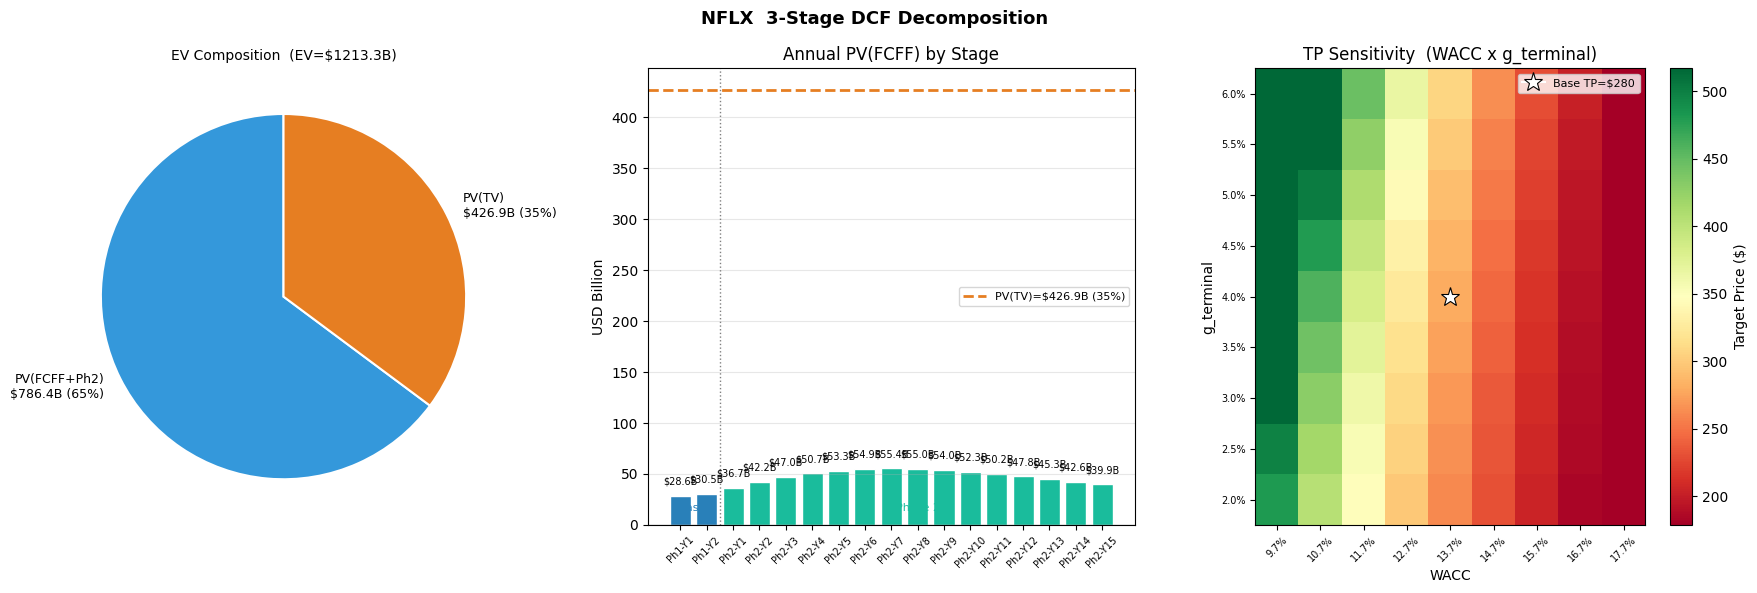

[Moat Analysis]
    ROIC (TTM)    : 32.85%
    WACC          : 13.72%
    EVA spread    : +19.14%
    Moat grade    : Wide moat
    AR(1) rho     : 0.832
    Phase2 period : 15 yr


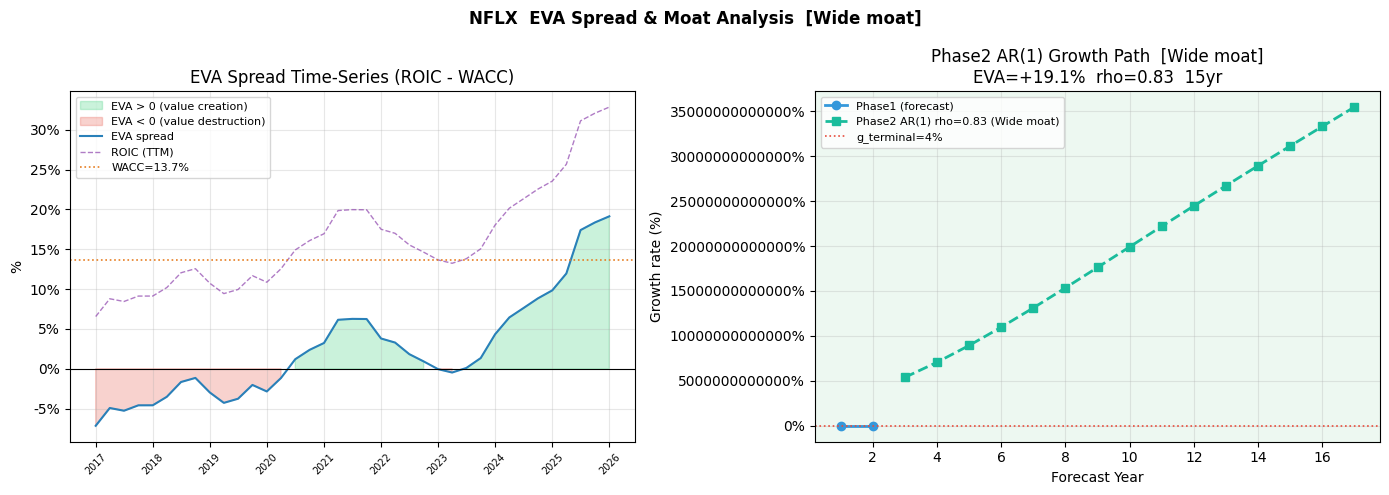

In [5]:
# ═══════════════════════════════════════════════════════════════
#  Cell 4.5 · 3-Stage DCF Decomposition & EVA Diagnostics
# ═══════════════════════════════════════════════════════════════

DIAG_TICKER = "NFLX"  # <- change ticker here

print(f"[Diagnostics] Running DCFModel for {DIAG_TICKER} ...")
_dm = DCFModel(ticker=DIAG_TICKER, engine=engine, verbose=True)
_dm.run()

v  = _dm.valuation
df = _dm.result_df.copy()
h  = _dm._fcff_history

wacc      = v["wacc"]
g_term    = v["g_terminal"]
ph1       = np.array(v["ph1_annual"])
ph2       = np.array(v["ph2_annual"])
g_ph2     = v["ph2_growth"]
all_ann   = np.array(v["all_annual"])
T_total   = v["t_total"]
fcff_last = v["fcff_last_annual"]
pv_fcff   = v["pv_fcff"]
tv        = v["terminal_value"]
pv_tv     = v["pv_tv"]
tv_wt     = v["tv_weight_pct"]
ev        = v["enterprise_value"]
net_debt  = v["net_debt"]
eq_val    = v["equity_value"]
shares    = v["shares"]
tp        = v["target_price"]
cp        = v["current_price"]

SEP = "=" * 66
print(f"\n{SEP}")
print(f"  {DIAG_TICKER}  3-Stage DCF Decomposition")
print(SEP)

print(f"\n[1] Discount rate")
print(f"    WACC          : {wacc*100:.4f}%")
print(f"    g_terminal    : {g_term*100:.4f}%")
print(f"    WACC - g      : {(wacc-g_term)*100:.4f}%")

print(f"\n[2] Phase 1 - Forecast FCFF (Year 1~{len(ph1)})")
cum = 0.0
for t, f in enumerate(ph1, 1):
    pv = f / (1+wacc)**t; cum += pv
    q0 = df["quarter"].iloc[(t-1)*4] if (t-1)*4 < len(df) else "?"
    q1 = df["quarter"].iloc[min(t*4-1, len(df)-1)]
    print(f"    Year {t} ({q0}~{q1})  FCFF={f/1e9:>8.3f}B  PV={pv/1e9:>8.3f}B  Cum={cum/1e9:>8.3f}B")

print(f"\n[3] Phase 2 - Growth convergence (Year {len(ph1)+1}~{len(ph1)+len(ph2)})")
for t_off, (f, g) in enumerate(zip(ph2, g_ph2), 1):
    yr = len(ph1) + t_off
    pv = f / (1+wacc)**yr; cum += pv
    print(f"    Year {yr}  g={g*100:>5.1f}%  FCFF={f/1e9:>8.3f}B  PV={pv/1e9:>8.3f}B  Cum={cum/1e9:>8.3f}B")

print(f"\n[4] Phase 3 - Terminal Value")
print(f"    Last annual FCFF : ${fcff_last/1e9:.3f}B")
print(f"    TV = {fcff_last/1e9:.3f}B x {1+g_term:.4f} / {wacc-g_term:.4f} = ${tv/1e9:.3f}B")
print(f"    PV(TV) = TV / (1+WACC)^{T_total} = ${pv_tv/1e9:.3f}B")

fcff_wt = pv_fcff / ev * 100 if ev != 0 else float("nan")
print(f"\n[5] EV Breakdown")
print(f"    PV(Phase1+2 FCFF) = ${pv_fcff/1e9:.3f}B  ({fcff_wt:.1f}%)")
print(f"    PV(TV)            = ${pv_tv/1e9:.3f}B  ({tv_wt:.1f}%)")
print(f"    Enterprise Value  = ${ev/1e9:.3f}B")

print(f"\n[6] Equity Bridge")
print(f"    EV ${ev/1e9:.3f}B  -  Net Debt ${net_debt/1e9:.3f}B  =  Equity ${eq_val/1e9:.3f}B")
tp_str = f"${tp:.2f}" if not np.isnan(tp) else "N/A"
up_str = f"{v['upside_pct']:.1f}%" if not np.isnan(v.get('upside_pct', float('nan'))) else "N/A"
print(f"    / {shares/1e6:.0f}M shares  =  TP {tp_str}  (Current ${cp:.2f}, Upside {up_str})")

print(f"\n{SEP}\n")

# ════════════════════════════════════════════════════════════════
# Visualisation  (1 x 3)
# ════════════════════════════════════════════════════════════════
_ev_positive = ev > 0 and pv_fcff > 0 and pv_tv > 0

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"{DIAG_TICKER}  3-Stage DCF Decomposition", fontsize=13, fontweight="bold")

# ── A: EV composition pie ────────────────────────────────────────
ax = axes[0]
if _ev_positive:
    ax.pie(
        [pv_fcff, pv_tv],
        labels=[f"PV(FCFF+Ph2)\n${pv_fcff/1e9:.1f}B ({fcff_wt:.0f}%)",
                f"PV(TV)\n${pv_tv/1e9:.1f}B ({tv_wt:.0f}%)"],
        colors=["#3498db", "#e67e22"],
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
        textprops=dict(fontsize=9),
    )
    ax.set_title(f"EV Composition  (EV=${ev/1e9:.1f}B)", fontsize=10)
else:
    ax.axis("off")
    msg  = f"EV = ${ev/1e9:.1f}B\n"
    msg += f"PV(FCFF) = ${pv_fcff/1e9:.1f}B\n"
    msg += f"PV(TV)   = ${pv_tv/1e9:.1f}B\n\n"
    msg += "Negative EV: pie chart\nnot applicable."
    ax.text(0.5, 0.5, msg, transform=ax.transAxes,
            ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#ffeeba", alpha=0.9))
    ax.set_title("EV Composition  (negative — chart skipped)", fontsize=10)

# ── B: Annual PV(FCFF) bar + PV(TV) line ────────────────────────
ax = axes[1]
yr_labels  = [f"Ph1-Y{i+1}" for i in range(len(ph1))] +              [f"Ph2-Y{i+1}" for i in range(len(ph2))]
pv_yr      = [f / (1+wacc)**(t+1) for t, f in enumerate(all_ann)]
colors_yr  = (["#2980b9"] * len(ph1)) + (["#1abc9c"] * len(ph2))

ax.bar(yr_labels, [v_ / 1e9 for v_ in pv_yr], color=colors_yr, edgecolor="white")
ax.axhline(pv_tv / 1e9, color="#e67e22", lw=2.0, ls="--",
           label=f"PV(TV)=${pv_tv/1e9:.1f}B ({tv_wt:.0f}%)")
ax.axvline(len(ph1) - 0.5, color="gray", lw=1, ls=":")

_ylim = ax.get_ylim()
_y_txt = _ylim[0] + (_ylim[1] - _ylim[0]) * 0.03
ax.text(len(ph1)/2 - 0.5, _y_txt, "Phase 1", ha="center", fontsize=8, color="#2980b9")
ax.text(len(ph1) + len(ph2)/2 - 0.5, _y_txt, "Phase 2", ha="center", fontsize=8, color="#1abc9c")

for i, val in enumerate(pv_yr):
    offset = abs(_ylim[1] - _ylim[0]) * 0.02
    va = "bottom" if val >= 0 else "top"
    y_pos = val/1e9 + (offset if val >= 0 else -offset)
    ax.text(i, y_pos, f"${val/1e9:.1f}B", ha="center", va=va, fontsize=7)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Annual PV(FCFF) by Stage")
ax.set_ylabel("USD Billion")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# ── C: WACC x g sensitivity heatmap ─────────────────────────────
ax = axes[2]
wacc_range = np.arange(max(wacc - 0.04, 0.04), wacc + 0.045, 0.01)
g_range    = np.arange(max(g_term - 0.02, 0.0), g_term + 0.025, 0.005)

tp_mat = np.full((len(g_range), len(wacc_range)), np.nan)
for ri, g_ in enumerate(g_range):
    for ci, w_ in enumerate(wacc_range):
        if w_ - g_ < 0.005:
            continue
        pv_f = sum(all_ann[t] / (1+w_)**(t+1) for t in range(T_total))
        tv_  = fcff_last * (1+g_) / (w_ - g_)
        ev_  = pv_f + tv_ / (1+w_)**T_total
        if shares > 0:
            tp_mat[ri, ci] = (ev_ - net_debt) / shares

_valid = tp_mat[~np.isnan(tp_mat)]
if len(_valid) > 0:
    im = ax.imshow(tp_mat, aspect="auto", cmap="RdYlGn",
                   vmin=np.nanpercentile(tp_mat, 10),
                   vmax=np.nanpercentile(tp_mat, 90),
                   origin="lower")
    plt.colorbar(im, ax=ax, label="Target Price ($)")
    ax.set_xticks(range(len(wacc_range)))
    ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_range], rotation=45, fontsize=7)
    ax.set_yticks(range(len(g_range)))
    ax.set_yticklabels([f"{g_*100:.1f}%" for g_ in g_range], fontsize=7)
    ax.set_xlabel("WACC")
    ax.set_ylabel("g_terminal")
    ax.set_title("TP Sensitivity  (WACC x g_terminal)")
    ci_cur = np.argmin(np.abs(wacc_range - wacc))
    ri_cur = np.argmin(np.abs(g_range    - g_term))
    tp_str2 = f"${tp:.0f}" if not np.isnan(tp) else "N/A"
    ax.plot(ci_cur, ri_cur, marker="*", ms=14, color="white",
            markeredgecolor="black", markeredgewidth=0.8,
            label=f"Base TP={tp_str2}")
    ax.legend(fontsize=8)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "All TP values invalid\n(negative FCFF / EV)",
            transform=ax.transAxes, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#ffeeba", alpha=0.9))
    ax.set_title("TP Sensitivity  (skipped)")

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
# EVA spread time-series + Moat diagnostics
# ════════════════════════════════════════════════════════════════
eva_series = v.get("eva_series", [])
moat_label = v.get("moat_label", "N/A")
eva_spread = v.get("eva_spread", np.nan)
roic_val   = v.get("roic",       np.nan)
moat_rho   = v.get("moat_rho",   np.nan)
n_ph2      = v.get("n_phase2",   0)

print("[Moat Analysis]")
print(f"    ROIC (TTM)    : {roic_val*100:.2f}%" if not np.isnan(roic_val) else "    ROIC      : N/A")
print(f"    WACC          : {wacc*100:.2f}%")
print(f"    EVA spread    : {eva_spread*100:+.2f}%" if not np.isnan(eva_spread) else "    EVA spread : N/A")
print(f"    Moat grade    : {moat_label}")
print(f"    AR(1) rho     : {moat_rho:.3f}" if not np.isnan(moat_rho) else "    rho       : N/A")
print(f"    Phase2 period : {n_ph2} yr")

if eva_series:
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    fig2.suptitle(f"{DIAG_TICKER}  EVA Spread & Moat Analysis  [{moat_label}]",
                  fontsize=12, fontweight="bold")

    # ── EVA spread time-series ────────────────────────────────────
    ax = axes2[0]
    dates_e = [e["date"] for e in eva_series]
    spreads = [e["eva_spread"] * 100 for e in eva_series]
    roics   = [e["roic"]       * 100 for e in eva_series]

    ax.fill_between(dates_e, spreads, 0,
                    where=[s > 0 for s in spreads],
                    color="#2ecc71", alpha=0.25, label="EVA > 0 (value creation)")
    ax.fill_between(dates_e, spreads, 0,
                    where=[s <= 0 for s in spreads],
                    color="#e74c3c", alpha=0.25, label="EVA < 0 (value destruction)")
    ax.plot(dates_e, spreads, color="#2980b9", lw=1.5, label="EVA spread")
    ax.plot(dates_e, roics,   color="#8e44ad", lw=1.0, ls="--", alpha=0.7, label="ROIC (TTM)")
    ax.axhline(0,           color="black",   lw=0.8)
    ax.axhline(wacc * 100,  color="#e67e22", lw=1.2, ls=":", label=f"WACC={wacc*100:.1f}%")
    ax.set_title("EVA Spread Time-Series (ROIC - WACC)")
    ax.set_ylabel("%")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # ── Moat grade + AR(1) growth path ───────────────────────────
    ax = axes2[1]
    _g0 = (ph2[0] / ph1[-1] - 1) if (len(ph1) > 0 and ph1[-1] > 0 and len(ph2) > 0) else 0.10
    _g0 = float(np.clip(_g0, 0.0, 0.80))
    yrs_ph2 = list(range(3, 3 + n_ph2))
    ph2_pct = [f * 100 for f in ph2[:n_ph2]] if len(ph2) >= n_ph2 else [_g0 * 100] * n_ph2

    ax.plot([1, 2], [_g0 * 100, _g0 * 100],
            "o-", color="#3498db", lw=2, label="Phase1 (forecast)")
    if yrs_ph2 and ph2_pct:
        ax.plot(yrs_ph2, ph2_pct, "s--", color="#1abc9c", lw=2,
                label=f"Phase2 AR(1) rho={moat_rho:.2f} ({moat_label})" if not np.isnan(moat_rho) else "Phase2")
    ax.axhline(GDP_GROWTH * 100, color="#e74c3c", lw=1.2, ls=":",
               label=f"g_terminal={GDP_GROWTH*100:.0f}%")

    moat_colors = {"Wide moat":   "#27ae60", "Narrow moat": "#2980b9",
                   "Some moat":   "#f39c12", "No moat":     "#e74c3c"}
    ax.set_facecolor(moat_colors.get(moat_label, "#95a5a6") + "15")

    eva_str = f"{eva_spread*100:+.1f}%" if not np.isnan(eva_spread) else "N/A"
    rho_str = f"{moat_rho:.2f}"         if not np.isnan(moat_rho)   else "N/A"
    ax.set_title(f"Phase2 AR(1) Growth Path  [{moat_label}]\n"
                 f"EVA={eva_str}  rho={rho_str}  {n_ph2}yr")
    ax.set_xlabel("Forecast Year")
    ax.set_ylabel("Growth rate (%)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("  [No EVA series — insufficient IS/BS data]")


## Cell 5 · 배치 실행

> `TICKER_START / TICKER_END` 로 범위 조정, `SKIP_DONE=True` 로 재시작 지원

In [6]:
# ─────────────────────────────────────────────────────────────────
# Cell 5 · 배치 실행
# ─────────────────────────────────────────────────────────────────

RUN_TICKERS = US_TICKER_LIST[TICKER_START:TICKER_END]
total   = len(RUN_TICKERS)
run_date = datetime.now().strftime("%Y-%m-%d")

done_set = set()
if SKIP_DONE and os.path.exists(DONE_PATH):
    with open(DONE_PATH) as f:
        done_set = {l.strip() for l in f if l.strip()}

ok_cnt = skip_cnt = fail_cnt = 0
results = []
t0 = time.time()

log("BATCH", f"배치 시작: {total:,}개  run_date={run_date}  SKIP_DONE={SKIP_DONE}")
print("=" * 70)

for idx, ticker in enumerate(RUN_TICKERS, 1):
    pct    = idx / total * 100
    prefix = f"[{idx:>5}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE and ticker in done_set:
        print(f"{prefix} SKIP (checkpoint)", flush=True)
        skip_cnt += 1
        continue

    res = process_one_ticker(ticker, engine, verbose=False,
                              run_date=run_date, save_db=True)
    results.append(res)

    if res["status"] == "ok":
        tp  = res["target_price"]
        up  = res["upside_pct"]
        w   = res["wacc"]
        tp_str = f"TP=${tp:.2f}" if not np.isnan(tp) else "TP=N/A"
        up_str = f"↑{up:.1f}%" if not np.isnan(up) else ""
        print(f"{prefix} OK  {tp_str} {up_str}  WACC={w:.3f}", flush=True)
        with open(DONE_PATH, "a") as f:
            f.write(ticker + "\n")
        ok_cnt += 1
    else:
        print(f"{prefix} FAIL  {res['msg']}", flush=True)
        with open(FAIL_PATH, "a") as f:
            f.write(ticker + "\n")
        fail_cnt += 1

elapsed = time.time() - t0
print("=" * 70)
log("BATCH", f"완료  OK={ok_cnt}  SKIP={skip_cnt}  FAIL={fail_cnt}  "
             f"경과={elapsed:.0f}s  평균={elapsed/max(ok_cnt+fail_cnt,1):.1f}s/ticker")

# 결과 요약
if results:
    summary = pd.DataFrame(results)
    summary = summary[summary["status"]=="ok"].sort_values("upside_pct", ascending=False)
    print("\n[상위 업사이드 종목 TOP 20]")
    display(summary[["ticker","target_price","upside_pct","wacc","g_terminal"]].head(20))


[00:19:41][BATCH] 배치 시작: 1,000개  run_date=2026-04-16  SKIP_DONE=True
[    1/1000] (  0.1%) NVDA     SKIP (checkpoint)
[    2/1000] (  0.2%) GOOG     SKIP (checkpoint)
[    3/1000] (  0.3%) AAPL     SKIP (checkpoint)
[    4/1000] (  0.4%) MSFT     SKIP (checkpoint)
[    5/1000] (  0.5%) AMZN     SKIP (checkpoint)
[    6/1000] (  0.6%) TSM      SKIP (checkpoint)
[    7/1000] (  0.7%) META     SKIP (checkpoint)
[    8/1000] (  0.8%) AVGO     SKIP (checkpoint)
[    9/1000] (  0.9%) TSLA     SKIP (checkpoint)
[   10/1000] (  1.0%) LLY      SKIP (checkpoint)
[   11/1000] (  1.1%) WMT      SKIP (checkpoint)
[   12/1000] (  1.2%) XOM      SKIP (checkpoint)
[   13/1000] (  1.3%) ASML     SKIP (checkpoint)
[   14/1000] (  1.4%) JNJ      SKIP (checkpoint)
[   15/1000] (  1.5%) ORCL     SKIP (checkpoint)
[   16/1000] (  1.6%) MU       SKIP (checkpoint)
[   17/1000] (  1.7%) COST     SKIP (checkpoint)
[   18/1000] (  1.8%) AMD      SKIP (checkpoint)
[   19/1000] (  1.9%) BABA     SKIP (checkpoint)


,ticker,target_price,upside_pct,wacc,g_terminal


## Cell 6 · 결과 조회 & 시각화

> `VIZ_TICKERS` 를 원하는 종목으로 변경

[DB 현황] us_fcff_dcf_valuation


,run_date,tickers,total_rows,avg_tp,avg_upside
0,2026-04-10,93,716,3611.986302,3349.449996
1,2026-04-09,13,108,180.791656,-51.694137



[최신 run_date: 2026-04-10]  총 93개 종목

🔼 업사이드 TOP 20


,ticker,target_price,current_price,upside_pct,wacc,g_terminal
0,SONY,36101.201294,21.0300,171565.246288,0.040000,0.030000
1,TM,234755.918389,211.1400,111084.957085,0.040000,0.030000
2,VZA,1274.317985,25.5500,4887.545931,0.040000,0.030000
3,ANTM,20895.784296,482.5800,4230.014567,0.117027,0.040000
4,T,461.921774,26.4800,1644.417575,0.048507,0.038507
5,NVO,480.237151,37.4400,1182.684697,0.087344,0.040000
6,BTI,656.470801,58.9900,1012.850993,0.069080,0.040000
7,BMY,553.928080,59.2600,834.741952,0.063697,0.040000
8,BUD,602.348470,75.8700,693.921800,0.075925,0.040000
9,VZ,331.308183,46.7650,608.453294,0.044756,0.034756



🔽 다운사이드 TOP 20


,ticker,target_price,current_price,upside_pct,wacc,g_terminal
73,ADI,167.622845,354.010,-52.650251,0.144497,0.04
74,PANW,74.396817,158.800,-53.150619,0.137740,0.04
75,KLAC,800.718811,1727.260,-53.955215,0.168962,0.04
76,AMD,107.894898,236.640,-54.405469,0.187165,0.04
77,TXN,93.568751,216.690,-56.819073,0.130393,0.04
78,LRCX,101.117043,258.760,-60.922460,0.178227,0.04
79,A,44.945352,115.370,-61.042427,0.117461,0.04
80,AAPL,93.785647,260.490,-63.996450,0.137729,0.04
81,ISRG,151.021615,454.540,-66.774846,0.143941,0.04
82,PEP,44.399175,156.990,-71.718470,0.071585,0.04


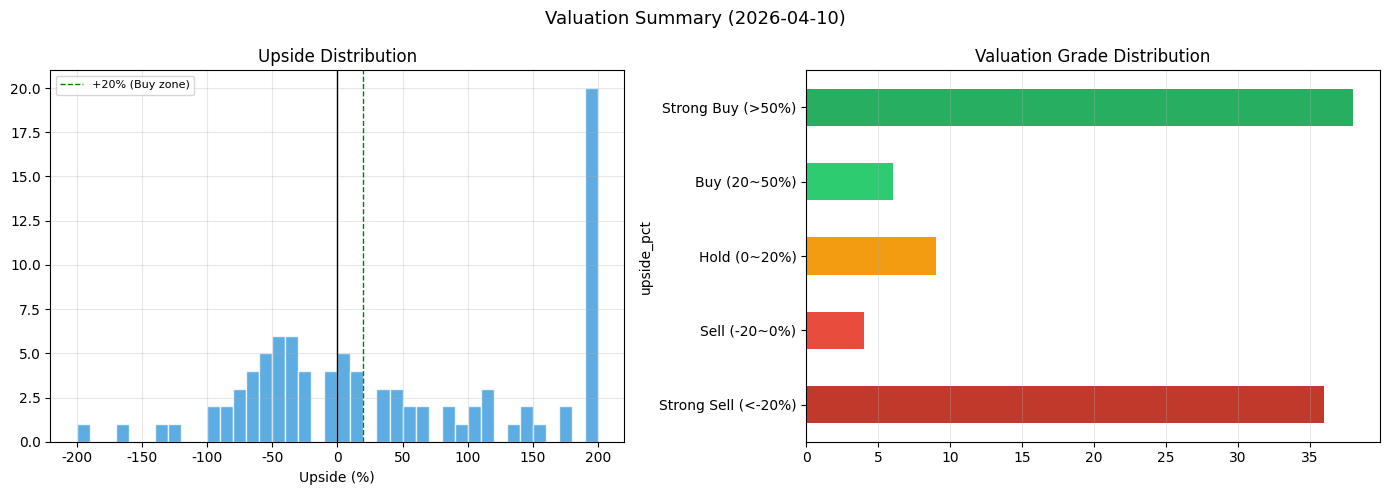


[개별 종목 시각화] ['AAPL', 'MSFT', 'NVDA']
[메모리] forecast_sarima 실행 전: 466.97 MB
[메모리] find_best_sarima_params 실행 전: 466.97 MB
[메모리] find_best_sarima_params 실행 후: 467.28 MB (변화: +0.30 MB)
[메모리] forecast_sarima 실행 후: 467.28 MB (변화: +0.30 MB)
[메모리] forecast_ets 실행 전: 467.28 MB
[메모리] forecast_ets 실행 후: 467.28 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 467.28 MB
[메모리] forecast_theta 실행 후: 467.28 MB (변화: +0.00 MB)


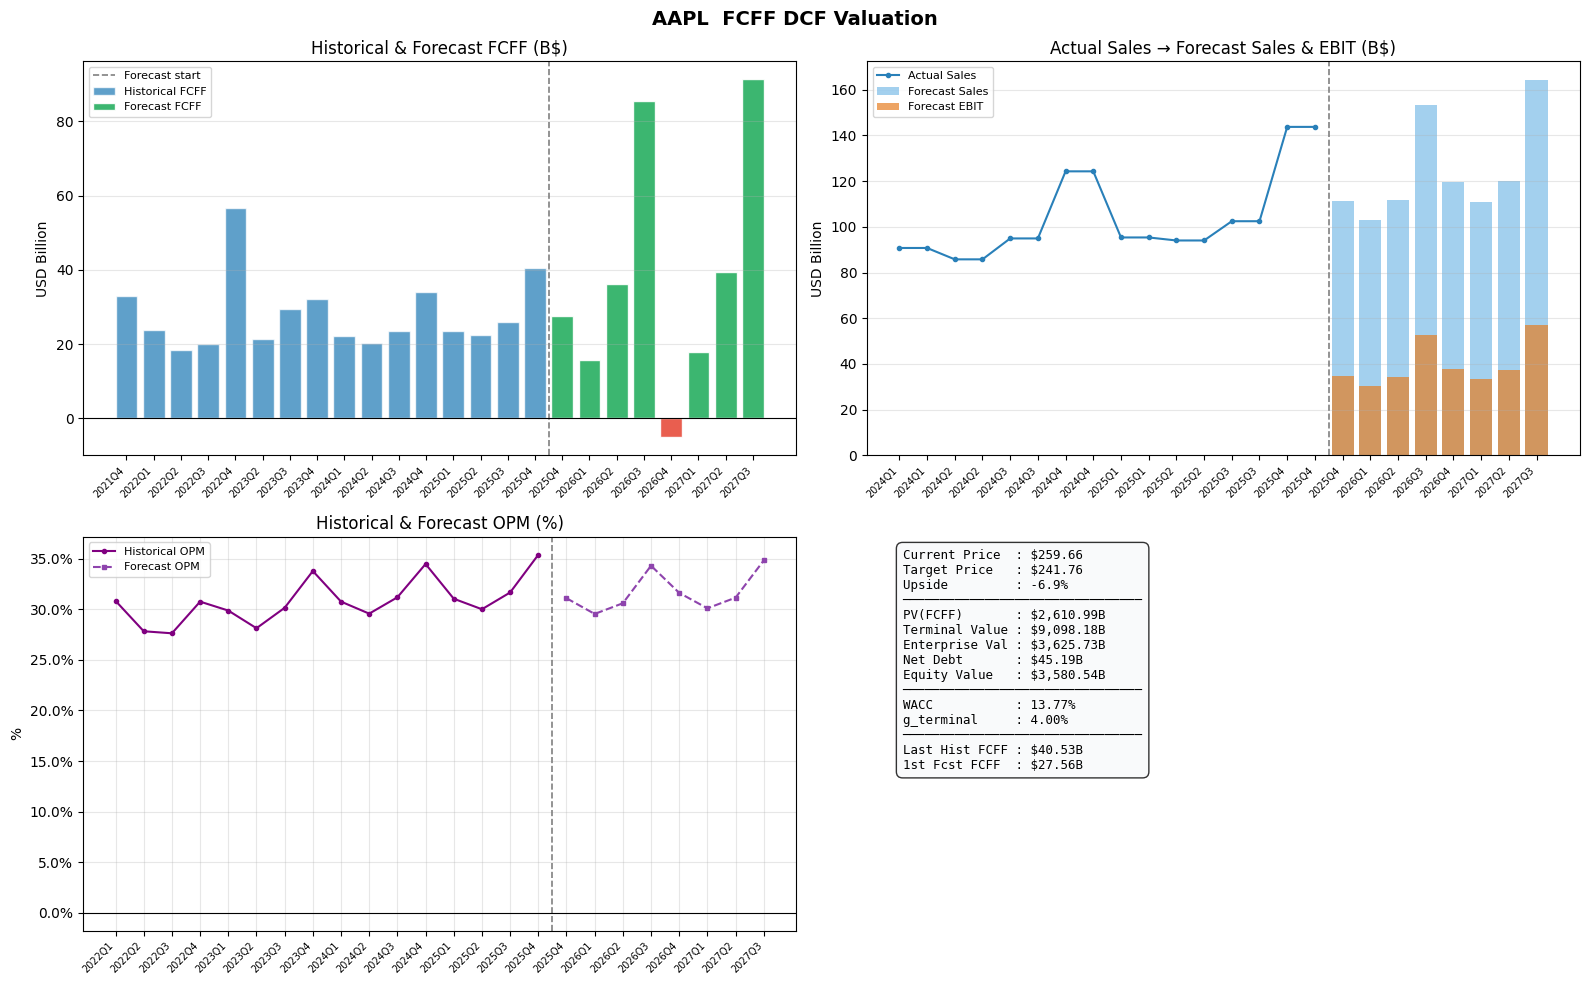

[메모리] forecast_sarima 실행 전: 476.60 MB
[메모리] find_best_sarima_params 실행 전: 476.60 MB
[메모리] find_best_sarima_params 실행 후: 471.65 MB (변화: -4.95 MB)
[메모리] forecast_sarima 실행 후: 471.65 MB (변화: -4.95 MB)
[메모리] forecast_ets 실행 전: 471.65 MB
[메모리] forecast_ets 실행 후: 471.65 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 471.65 MB
[메모리] forecast_theta 실행 후: 471.65 MB (변화: +0.00 MB)


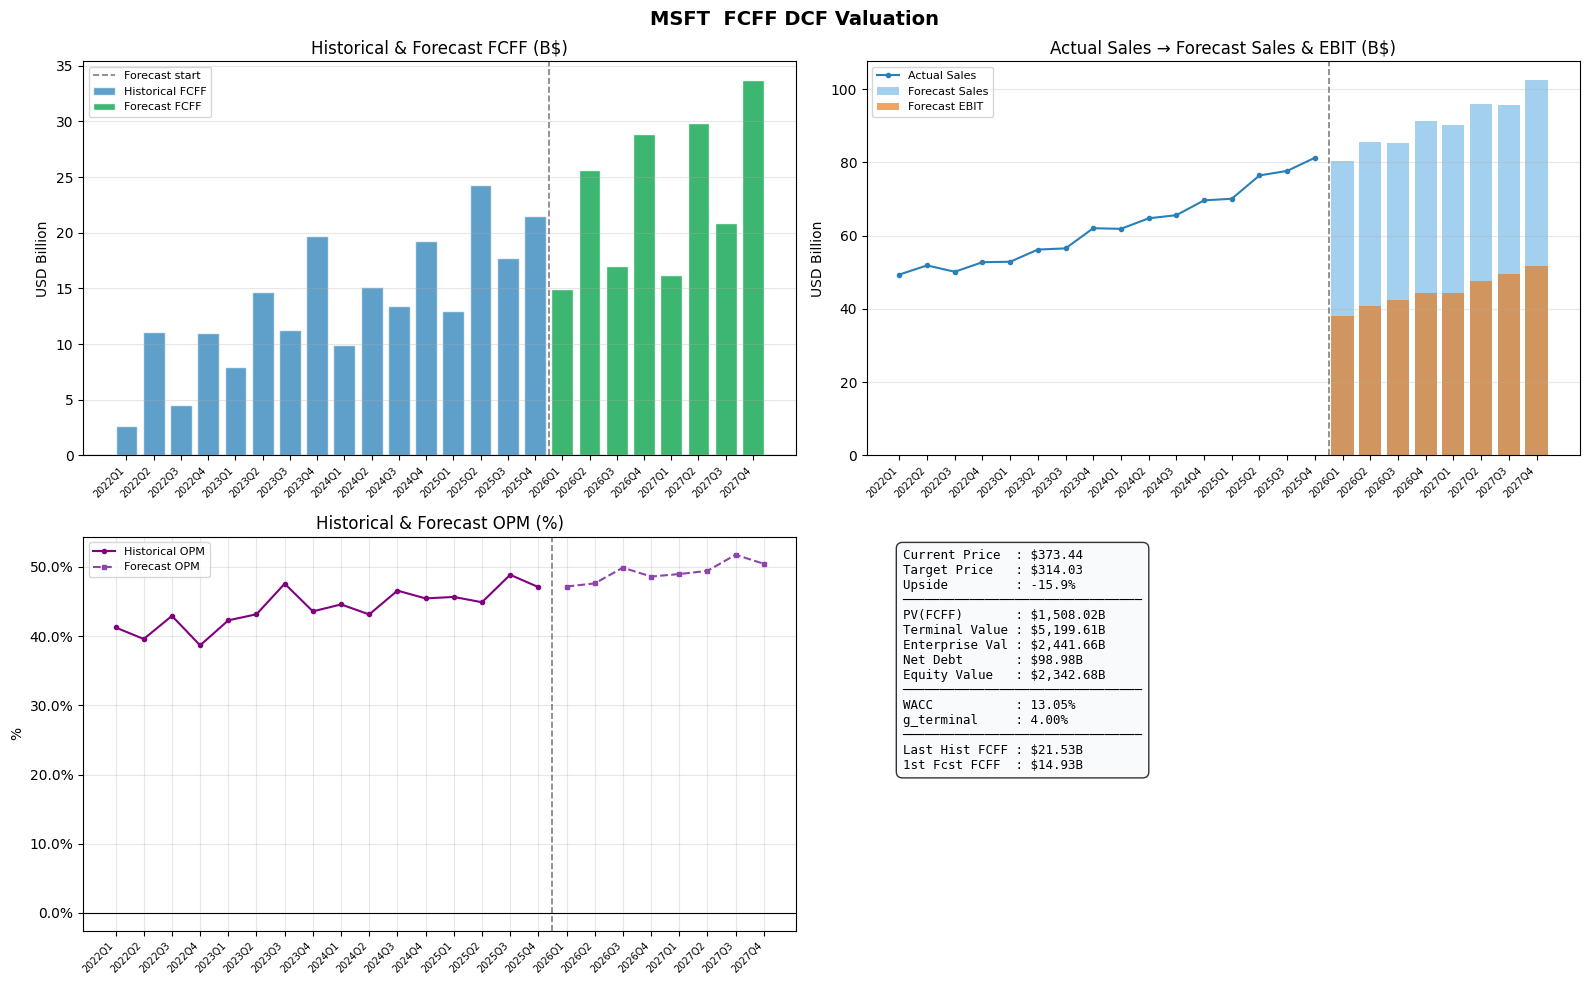

[메모리] forecast_sarima 실행 전: 477.77 MB
[메모리] find_best_sarima_params 실행 전: 477.77 MB
[메모리] find_best_sarima_params 실행 후: 472.20 MB (변화: -5.57 MB)
[메모리] forecast_sarima 실행 후: 472.20 MB (변화: -5.57 MB)
[메모리] forecast_ets 실행 전: 472.20 MB
[메모리] forecast_ets 실행 후: 472.20 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 472.20 MB
[메모리] forecast_theta 실행 후: 472.20 MB (변화: +0.00 MB)


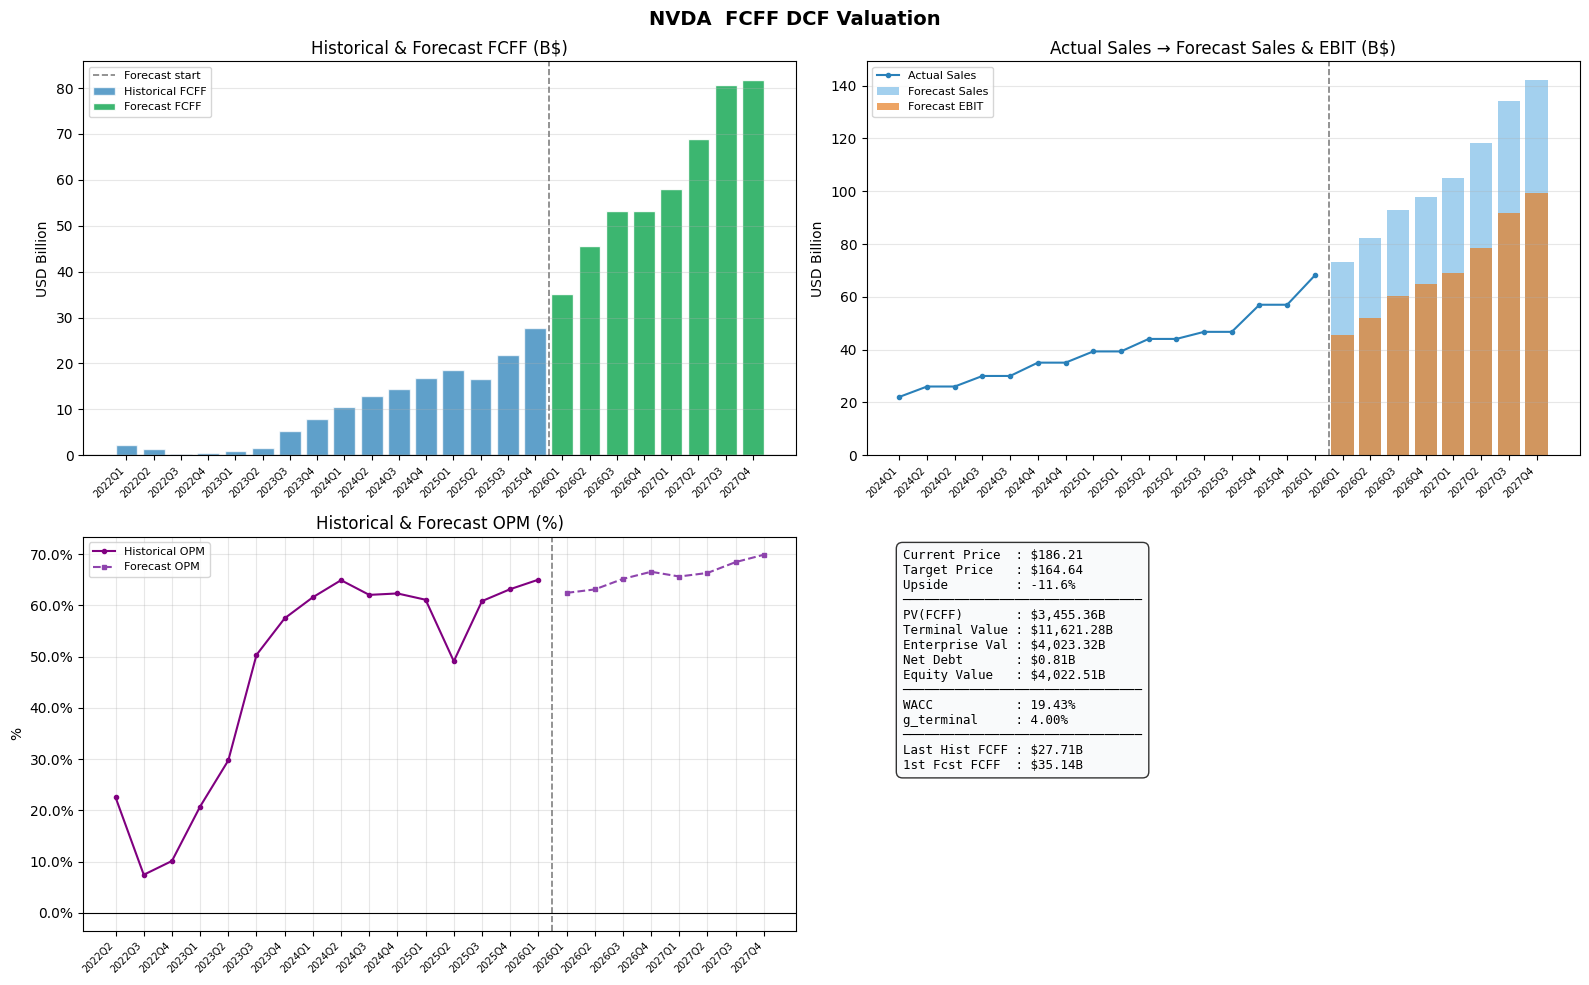

In [7]:
# ─────────────────────────────────────────────────────────────────
# Cell 6 · 결과 조회 & 시각화
# ─────────────────────────────────────────────────────────────────

# ── 6-1. DB 현황 ─────────────────────────────────────────────────
conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT DATE(date) AS run_date,
                   COUNT(DISTINCT ticker) AS tickers,
                   COUNT(*) AS total_rows,
                   AVG(target_price) AS avg_tp,
                   AVG(upside_pct) AS avg_upside
            FROM {TABLE_RESULT}
            GROUP BY DATE(date)
            ORDER BY run_date DESC
            LIMIT 10
        """)
        _summary = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print("=" * 60)
print(f"[DB 현황] {TABLE_RESULT}")
print("=" * 60)
display(_summary)

# ── 6-2. 최신 run_date 기준 업사이드 상위/하위 ────────────────────
conn = get_conn()
try:
    with conn.cursor() as cur:
        # 최신 run_date 찾기
        cur.execute(f"SELECT MAX(date) AS max_date FROM {TABLE_RESULT}")
        max_date = cur.fetchone()["max_date"]

        if max_date:
            cur.execute(f"""
                SELECT ticker, MAX(target_price) AS target_price,
                       MAX(current_price) AS current_price,
                       MAX(upside_pct) AS upside_pct,
                       MAX(discount_rate) AS wacc,
                       MAX(g_terminal) AS g_terminal
                FROM {TABLE_RESULT}
                WHERE date = %s AND target_price IS NOT NULL
                GROUP BY ticker
                ORDER BY upside_pct DESC
            """, (max_date,))
            results_df = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

if max_date and not results_df.empty:
    print(f"\n[최신 run_date: {max_date}]  총 {len(results_df)}개 종목")

    print("\n🔼 업사이드 TOP 20")
    display(results_df.head(20)[["ticker","target_price","current_price","upside_pct","wacc","g_terminal"]])

    print("\n🔽 다운사이드 TOP 20")
    display(results_df.tail(20)[["ticker","target_price","current_price","upside_pct","wacc","g_terminal"]])

    # 업사이드 분포 히스토그램
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Valuation Summary ({max_date})", fontsize=13)

    ax = axes[0]
    upside_clean = results_df["upside_pct"].dropna().clip(-200, 200)
    ax.hist(upside_clean, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(20, color="green", lw=1, ls="--", label="+20% (Buy zone)")
    ax.set_title("Upside Distribution"); ax.set_xlabel("Upside (%)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[1]
    grade_counts = pd.cut(results_df["upside_pct"],
                          bins=[-np.inf, -20, 0, 20, 50, np.inf],
                          labels=["Strong Sell (<-20%)", "Sell (-20~0%)",
                                  "Hold (0~20%)", "Buy (20~50%)", "Strong Buy (>50%)"])
    grade_counts.value_counts().sort_index().plot(
        kind="barh", ax=ax,
        color=["#c0392b","#e74c3c","#f39c12","#2ecc71","#27ae60"]
    )
    ax.set_title("Valuation Grade Distribution"); ax.grid(axis="x", alpha=0.3)

    plt.tight_layout(); plt.show()
else:
    print("[INFO] 데이터 없음 — Cell 5 배치 실행 후 재시도")

# ── 6-3. 개별 종목 시각화 ────────────────────────────────────────
VIZ_TICKERS = ["AAPL", "MSFT", "NVDA"]   # ← 원하는 종목으로 변경

print(f"\n[개별 종목 시각화] {VIZ_TICKERS}")
for tk in VIZ_TICKERS:
    try:
        m = DCFModel(ticker=tk, engine=engine, verbose=False).run()
        m.plot()
    except Exception as e:
        print(f"  [{tk}] 시각화 실패: {e}")


## Cell 7 · Sensitivity Analysis (WACC x g_terminal)

> Set `SENS_TICKERS` to the tickers you want to analyse.  
> Visualises Target Price changes across WACC ±4pp and g_terminal ±2pp ranges  
> via heatmap, tornado chart, and Monte Carlo simulation.


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  Cell 7 · Sensitivity Analysis
#  ─ 2D heatmap : WACC × g_terminal  →  Target Price / Upside %
#  ─ Tornado chart : single-param sweep  →  TP range
#  ─ Monte Carlo   : input uncertainty  →  TP distribution
# ═══════════════════════════════════════════════════════════════

SENS_TICKERS = ["MSFT", "NVDA", "AAPL"]   # <- tickers to analyse

# ── Parameter ranges ─────────────────────────────────────────────
WACC_STEPS  = 9     # WACC grid points
G_STEPS     = 7     # g_terminal grid points
WACC_DELTA  = 0.04  # base WACC ± 4 pp
G_DELTA     = 0.02  # base g    ± 2 pp
MC_RUNS     = 2000  # Monte Carlo iterations

# ── Fast scalar DCF helper ────────────────────────────────────────
def _dcf_tp(all_annual, fcff_last, net_debt, shares, wacc, g):
    """Annual FCFF array + params -> Target Price (scalar)"""
    if wacc - g < 0.005 or shares <= 0:
        return np.nan
    pv_f  = sum(all_annual[t] / (1 + wacc) ** (t + 1)
                for t in range(len(all_annual)))
    tv    = fcff_last * (1 + g) / (wacc - g)
    pv_tv = tv / (1 + wacc) ** len(all_annual)
    return max((pv_f + pv_tv - net_debt) / shares, 0)


for SENS_TICKER in SENS_TICKERS:
    print(f"\n{'='*64}")
    print(f"  Sensitivity Analysis: {SENS_TICKER}")
    print(f"{'='*64}")

    try:
        _m = DCFModel(ticker=SENS_TICKER, engine=engine, verbose=False)
        _m.run()
    except Exception as e:
        print(f"  [{SENS_TICKER}] model failed: {e}")
        continue

    v          = _m.valuation
    wacc_base  = v["wacc"]
    g_base     = v["g_terminal"]
    all_annual = np.array(v["all_annual"])
    fcff_last  = v["fcff_last_annual"]
    net_debt   = v["net_debt"]
    shares     = v["shares"]
    tp_base    = v["target_price"]
    cp         = v["current_price"]
    moat_lbl   = v.get("moat_label", "N/A")
    n_ph2      = v.get("n_phase2",  0)

    if np.isnan(tp_base) or shares <= 0:
        print(f"  [{SENS_TICKER}] TP unavailable — skipping")
        continue

    print(f"  Base  WACC={wacc_base*100:.2f}%  g={g_base*100:.2f}%  "
          f"TP=${tp_base:.2f}  Moat={moat_lbl}  Phase2={n_ph2}yr")

    # ════════════════════════════════════════════════════════════
    # 1) 2-D heatmaps  (TP  &  Upside %)
    # ════════════════════════════════════════════════════════════
    wacc_arr = np.linspace(max(wacc_base - WACC_DELTA, 0.04),
                           wacc_base + WACC_DELTA, WACC_STEPS)
    g_arr    = np.linspace(max(g_base - G_DELTA, 0.00),
                           min(g_base + G_DELTA, 0.08), G_STEPS)

    tp_mat     = np.full((len(g_arr), len(wacc_arr)), np.nan)
    upside_mat = np.full_like(tp_mat, np.nan)

    for ri, g_ in enumerate(g_arr):
        for ci, w_ in enumerate(wacc_arr):
            tp_ = _dcf_tp(all_annual, fcff_last, net_debt, shares, w_, g_)
            if tp_ is not None and not np.isnan(tp_):
                tp_mat[ri, ci] = tp_
                if cp > 0:
                    upside_mat[ri, ci] = (tp_ / cp - 1) * 100

    # ════════════════════════════════════════════════════════════
    # 2) Tornado chart
    # ════════════════════════════════════════════════════════════
    tornado_params = {
        "WACC (+/-4pp)":      ("wacc", wacc_base - 0.04, wacc_base + 0.04),
        "g_terminal (+/-2pp)":("g",    max(g_base - 0.02, 0.005), g_base + 0.02),
        "WACC (+/-2pp)":      ("wacc", wacc_base - 0.02, wacc_base + 0.02),
        "g_terminal (+/-1pp)":("g",    max(g_base - 0.01, 0.005), g_base + 0.01),
        "FCFF x0.8 / x1.2":  ("fcff", 0.80, 1.20),
        "Net Debt x0.5/x1.5":("debt", 0.50, 1.50),
    }

    tornado_data = []
    for label, (ptype, lo, hi) in tornado_params.items():
        if ptype == "wacc":
            tp_lo = _dcf_tp(all_annual, fcff_last, net_debt, shares, lo, g_base)
            tp_hi = _dcf_tp(all_annual, fcff_last, net_debt, shares, hi, g_base)
        elif ptype == "g":
            tp_lo = _dcf_tp(all_annual, fcff_last, net_debt, shares, wacc_base, lo)
            tp_hi = _dcf_tp(all_annual, fcff_last, net_debt, shares, wacc_base, hi)
        elif ptype == "fcff":
            tp_lo = _dcf_tp(all_annual * lo, fcff_last * lo, net_debt, shares, wacc_base, g_base)
            tp_hi = _dcf_tp(all_annual * hi, fcff_last * hi, net_debt, shares, wacc_base, g_base)
        elif ptype == "debt":
            tp_lo = _dcf_tp(all_annual, fcff_last, net_debt * hi, shares, wacc_base, g_base)
            tp_hi = _dcf_tp(all_annual, fcff_last, net_debt * lo, shares, wacc_base, g_base)
        else:
            continue
        if tp_lo is not None and tp_hi is not None:
            tornado_data.append((label, tp_lo, tp_hi))

    tornado_data.sort(key=lambda x: abs(x[2] - x[1]), reverse=True)

    # ════════════════════════════════════════════════════════════
    # 3) Monte Carlo
    # ════════════════════════════════════════════════════════════
    np.random.seed(42)
    mc_wacc   = np.random.normal(wacc_base, 0.015, MC_RUNS)
    mc_g      = np.random.normal(g_base,    0.008, MC_RUNS)
    mc_fcff_s = np.random.normal(1.0,       0.10,  MC_RUNS)

    mc_tp = []
    for w_, g_, fs_ in zip(mc_wacc, mc_g, mc_fcff_s):
        if w_ - g_ < 0.005 or w_ < 0.02:
            continue
        tp_ = _dcf_tp(all_annual * fs_, fcff_last * fs_, net_debt, shares, w_, g_)
        if tp_ is not None and not np.isnan(tp_) and 0 < tp_ < tp_base * 10:
            mc_tp.append(tp_)
    mc_tp = np.array(mc_tp)

    # ════════════════════════════════════════════════════════════
    # Visualisation (2x2)
    # ════════════════════════════════════════════════════════════
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        f"{SENS_TICKER}  Sensitivity Analysis  |  "
        f"Base TP=${tp_base:.2f}  CP=${cp:.2f}  "
        f"[{moat_lbl} / Phase2 {n_ph2}yr]",
        fontsize=13, fontweight="bold"
    )

    # ── (1) Target Price heatmap ──────────────────────────────────
    ax = axes[0, 0]
    vmin = np.nanpercentile(tp_mat, 5)
    vmax = np.nanpercentile(tp_mat, 95)
    im = ax.imshow(tp_mat, aspect="auto", cmap="RdYlGn",
                   vmin=vmin, vmax=vmax, origin="lower")
    plt.colorbar(im, ax=ax, label="Target Price ($)")

    ci_b = np.argmin(np.abs(wacc_arr - wacc_base))
    ri_b = np.argmin(np.abs(g_arr    - g_base))
    ax.plot(ci_b, ri_b, marker="*", ms=16, color="white",
            markeredgecolor="black", markeredgewidth=0.8, zorder=5,
            label=f"Base TP=${tp_base:.0f}")

    for ri in range(len(g_arr)):
        for ci in range(len(wacc_arr)):
            val = tp_mat[ri, ci]
            if not np.isnan(val):
                txt_col = "white" if (val < vmin * 1.1 or val > vmax * 0.9) else "black"
                ax.text(ci, ri, f"${val:.0f}", ha="center", va="center",
                        fontsize=7, color=txt_col)

    ax.set_xticks(range(len(wacc_arr)))
    ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_arr], rotation=45, fontsize=7)
    ax.set_yticks(range(len(g_arr)))
    ax.set_yticklabels([f"{g*100:.1f}%" for g in g_arr], fontsize=7)
    ax.set_xlabel("WACC")
    ax.set_ylabel("g_terminal")
    ax.set_title("Target Price  —  WACC x g heatmap")
    ax.legend(fontsize=8, loc="upper right")

    # ── (2) Upside % heatmap ──────────────────────────────────────
    ax = axes[0, 1]
    im2 = ax.imshow(upside_mat, aspect="auto", cmap="RdYlGn",
                    vmin=-50, vmax=100, origin="lower")
    plt.colorbar(im2, ax=ax, label="Upside (%)")
    ax.plot(ci_b, ri_b, marker="*", ms=16, color="white",
            markeredgecolor="black", markeredgewidth=0.8, zorder=5,
            label=f"Base TP=${tp_base:.0f}")

    for ri in range(len(g_arr)):
        for ci in range(len(wacc_arr)):
            val = upside_mat[ri, ci]
            if not np.isnan(val):
                ax.text(ci, ri, f"{val:+.0f}%", ha="center", va="center",
                        fontsize=7, color="black")

    ax.set_xticks(range(len(wacc_arr)))
    ax.set_xticklabels([f"{w*100:.1f}%" for w in wacc_arr], rotation=45, fontsize=7)
    ax.set_yticks(range(len(g_arr)))
    ax.set_yticklabels([f"{g*100:.1f}%" for g in g_arr], fontsize=7)
    ax.set_xlabel("WACC")
    ax.set_ylabel("g_terminal")
    ax.set_title("Upside (%)  —  WACC x g heatmap")
    ax.legend(fontsize=8, loc="upper right")

    # ── (3) Tornado chart ─────────────────────────────────────────
    ax = axes[1, 0]
    labels  = [t[0] for t in tornado_data]
    lo_vals = [t[1] for t in tornado_data]
    hi_vals = [t[2] for t in tornado_data]
    y_pos   = range(len(labels))

    for y, lo, hi in zip(y_pos, lo_vals, hi_vals):
        # green = favourable side, red = unfavourable side
        if lo < hi:
            ax.barh(y, hi - tp_base, left=tp_base,
                    color="#2ecc71", alpha=0.8, height=0.5)
            ax.barh(y, lo - tp_base, left=tp_base,
                    color="#e74c3c", alpha=0.8, height=0.5)
        else:
            ax.barh(y, lo - tp_base, left=tp_base,
                    color="#2ecc71", alpha=0.8, height=0.5)
            ax.barh(y, hi - tp_base, left=tp_base,
                    color="#e74c3c", alpha=0.8, height=0.5)
        ax.text(max(lo, hi) + tp_base * 0.01, y,
                f"${max(lo, hi):.0f}", va="center", fontsize=8)
        ax.text(min(lo, hi) - tp_base * 0.01, y,
                f"${min(lo, hi):.0f}", va="center", ha="right", fontsize=8)

    ax.axvline(tp_base, color="black", lw=1.5, ls="--",
               label=f"Base TP=${tp_base:.2f}")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Target Price ($)")
    ax.set_title("Tornado Chart  —  Parameter Sensitivity")
    ax.legend(fontsize=8)
    ax.grid(axis="x", alpha=0.3)

    # ── (4) Monte Carlo distribution ─────────────────────────────
    ax = axes[1, 1]
    if len(mc_tp) > 100:
        ax.hist(mc_tp, bins=60, color="#3498db", edgecolor="white",
                alpha=0.75, density=True,
                label=f"MC distribution (n={len(mc_tp):,})")
        ax.axvline(tp_base, color="black", lw=2.0, ls="--",
                   label=f"Base TP=${tp_base:.2f}")
        if not np.isnan(cp):
            ax.axvline(cp, color="#e74c3c", lw=2.0,
                       label=f"Current price ${cp:.2f}")

        p10, p25, p50, p75, p90 = np.percentile(mc_tp, [10, 25, 50, 75, 90])
        for pval, plbl, col in [
            (p10, "P10", "#e74c3c"),
            (p50, "P50", "#f39c12"),
            (p90, "P90", "#2ecc71"),
        ]:
            ax.axvline(pval, color=col, lw=1.2, ls=":",
                       label=f"{plbl}=${pval:.0f}")

        if not np.isnan(cp) and cp > 0:
            prob_up = (mc_tp > cp).mean() * 100
            ax.text(0.97, 0.95,
                    f"P(TP > current price) = {prob_up:.1f}%",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=10, fontweight="bold",
                    color="#2ecc71" if prob_up > 50 else "#e74c3c")

        ax.set_title(
            f"Monte Carlo TP Distribution\n"
            f"P50=${p50:.0f}   P10-P90: ${p10:.0f} - ${p90:.0f}"
        )
    else:
        ax.text(0.5, 0.5, "Insufficient MC data",
                transform=ax.transAxes, ha="center", va="center", fontsize=12)
        ax.set_title("Monte Carlo TP Distribution")

    ax.set_xlabel("Target Price ($)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Summary text ─────────────────────────────────────────────
    print(f"\n  [TP Range Summary]")
    print(f"    Heatmap range   : ${np.nanmin(tp_mat):.0f} - ${np.nanmax(tp_mat):.0f}")
    if len(mc_tp) > 100:
        print(f"    MC P10/P50/P90  : ${p10:.0f} / ${p50:.0f} / ${p90:.0f}")
        if not np.isnan(cp) and cp > 0:
            print(f"    P(TP > cur price): {prob_up:.1f}%")
    print(f"    Most sensitive  : {tornado_data[0][0]}  "
          f"(${min(tornado_data[0][1], tornado_data[0][2]):.0f}"
          f" - ${max(tornado_data[0][1], tornado_data[0][2]):.0f})")
